In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

In [7]:
### NIFTY 50 + NEXT 50 ( as of 2021 )

In [11]:
import time

nifty_100_tickers = [
    'ACC.NS', 'ADANIENT.NS', 'ADANIGREEN.NS', 'ADANIPORTS.NS', 'AMBUJACEM.NS',
    'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AUROPHARMA.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS',
    'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BANDHANBNK.NS', 'BANKBARODA.NS', 'BERGEPAINT.NS',
    'BEL.NS', 'BPCL.NS', 'BHARTIARTL.NS', 'BIOCON.NS', 'BOSCHLTD.NS',
    'BRITANNIA.NS', 'CHOLAFIN.NS', 'CIPLA.NS', 'COALINDIA.NS', 'COLPAL.NS',
    'CONCOR.NS', 'DABUR.NS', 'DIVISLAB.NS', 'DLF.NS', 'DRREDDY.NS',
    'EICHERMOT.NS', 'GAIL.NS', 'GODREJCP.NS', 'GRASIM.NS', 'HAVELLS.NS',
    'HCLTECH.NS', 'HDFCAMC.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HEROMOTOCO.NS',
    'HINDALCO.NS', 'HINDPETRO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ICICIGI.NS',
    'ICICIPRULI.NS', 'ITC.NS', 'IOC.NS', 'IGL.NS', 'INDUSINDBK.NS',
    'NAUKRI.NS', 'INFY.NS', 'INDIGO.NS', 'JSWSTEEL.NS', 'JUBLFOOD.NS',
    'KOTAKBANK.NS', 'LT.NS', 'LUPIN.NS', 'M&M.NS', 'MARICO.NS',
    'MARUTI.NS', 'MUTHOOTFIN.NS', 'NMDC.NS', 'NTPC.NS', 'NESTLEIND.NS',
    'ONGC.NS', 'PAGEIND.NS', 'PETRONET.NS', 'PIDILITIND.NS',
    'PIIND.NS', 'PFC.NS', 'POWERGRID.NS', 'PNB.NS', 'RECLTD.NS',
    'RELIANCE.NS', 'SBICARD.NS', 'SBILIFE.NS', 'SBIN.NS', 'SHREECEM.NS',
    'SIEMENS.NS', 'SRF.NS', 'SUNPHARMA.NS', 'TCS.NS', 'TATACONSUM.NS', 'TATASTEEL.NS', 'TECHM.NS', 'TITAN.NS', 'TORNTPHARM.NS',
    'UPL.NS', 'ULTRACEMCO.NS', 'VEDL.NS', 'WIPRO.NS', 'YESBANK.NS',
    'ZEEL.NS', 'AWL.NS', 'ATGL.NS', 'DMART.NS', 'LICI.NS'
]

In [12]:
### Downloading using yfinance 

In [15]:
def fetch_single_ticker_data(ticker, start_date, end_date):
    print(f"Downloading {ticker}")
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        
        if df.empty:
            return None

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)  #Flatten the data
        
        df = df.reset_index()
        df['Ticker'] = ticker      
        return df
        
    except Exception as e:
        print(f"Failed to download {ticker}: {e}")
        return None

if __name__ == "__main__":
    start = "2021-01-01"
    end = "2026-08-19"
    
    all_stock_data = []  
    
    for symbol in nifty_100_tickers:
        stock_df = fetch_single_ticker_data(symbol, start, end)
        
        if stock_df is not None:
            all_stock_data.append(stock_df)
            
        time.sleep(0.5)
        
    print("\nCombining all data")
    final_dataset = pd.concat(all_stock_data, ignore_index=True)
    
    cols = ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    cols = [c for c in cols if c in final_dataset.columns]
    final_dataset = final_dataset[cols]
    
    csv_filename = "nifty_100.csv"
    final_dataset.to_csv(csv_filename, index=False)
    print(f"Saved {len(final_dataset)} rows of data to {csv_filename}")


Combining all data
Saved 135994 rows of data to nifty_100.csv


In [16]:
## Downloadin Nifty 50 and India VIX data

In [300]:
vix_df = yf.download("^INDIAVIX", start="2021-01-01", end="2026-08-19", progress=False)
nifty_df = yf.download("^NSEI", start="2021-01-01", end="2026-08-19", progress=False)

if isinstance(vix_df.columns, pd.MultiIndex):
    vix_df.columns = vix_df.columns.droplevel(1)
if isinstance(nifty_df.columns, pd.MultiIndex):
    nifty_df.columns = nifty_df.columns.droplevel(1)

macro_df = pd.DataFrame()
macro_df['Date'] = pd.to_datetime(nifty_df.index).strftime('%Y-%m-%d')

macro_df['India_VIX'] = vix_df['Close'].values if len(vix_df) == len(nifty_df) else nifty_df.index.map(vix_df['Close']).values
macro_df['Nifty'] = nifty_df['Close'].values
macro_df['Nifty_Return'] = nifty_df['Close'].pct_change().values

print(macro_df.head())

         Date  India_VIX         Nifty  Nifty_Return
0  2021-01-01        NaN  14018.500000           NaN
1  2021-01-04  20.030001  14132.900391      0.008161
2  2021-01-05  20.459999  14199.500000      0.004712
3  2021-01-06  21.000000  14146.250000     -0.003750
4  2021-01-07  20.620001  14137.349609     -0.000629


In [301]:
# Loading the PCR option data

In [302]:
pcr_df = pd.read_csv("nifty_pcr_data.csv")
pcr_df['Date'] = pd.to_datetime(pcr_df['Date']).dt.strftime('%Y-%m-%d')

pcr_df.head()

,Date,NIFTY_Put_OI,NIFTY_Call_OI,NIFTY_Fut_OI,Total_Options_OI,PCR
0,2021-01-01,63556725.0,46307550.0,13154850.0,109864275.0,1.3725
1,2021-01-04,75260775.0,49468500.0,13716075.0,124729275.0,1.5214
2,2021-01-05,89125200.0,54993150.0,14254725.0,144118350.0,1.6207
3,2021-01-06,85296075.0,68451750.0,13431900.0,153747825.0,1.2461
4,2021-01-07,93355950.0,78445575.0,13371150.0,171801525.0,1.1901


In [303]:
# loading the Nifty 100 data

In [304]:
stocks_df = pd.read_csv("nifty_100.csv")
stocks_df['Date'] = pd.to_datetime(stocks_df['Date']).dt.strftime('%Y-%m-%d')

stock_df.head()

Price,Date,Close,High,Low,Open,Volume,Ticker
0,2022-05-17,415.193451,435.923481,407.959289,413.651744,97585754,LICI.NS
1,2022-05-18,415.715302,422.664853,414.647966,420.079524,17839522,LICI.NS
2,2022-05-19,398.875122,411.279944,397.523175,411.279944,14744854,LICI.NS
3,2022-05-20,391.901855,406.441318,391.356317,402.527755,14156582,LICI.NS
4,2022-05-23,387.490204,404.496433,381.228526,391.901880,24889296,LICI.NS


In [305]:
# Merging all the data together 

In [306]:
daily_regime_df = pd.merge(macro_df, pcr_df, on='Date', how='inner')
master_panel = pd.merge(stocks_df, daily_regime_df, on='Date', how='left')


master_panel = master_panel.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)
master_panel.to_csv("master_equity_panel.csv", index=False)

master_panel.head()

,Date,Ticker,Open,High,Low,Close,Volume,India_VIX,Nifty,Nifty_Return,NIFTY_Put_OI,NIFTY_Call_OI,NIFTY_Fut_OI,Total_Options_OI,PCR
0,2021-01-01,ACC.NS,1534.297550,1548.338905,1532.827077,1542.741333,647892,NaN,14018.500000,NaN,63556725.0,46307550.0,13154850.0,109864275.0,1.3725
1,2021-01-04,ACC.NS,1550.236281,1564.467336,1544.543859,1557.256958,1446174,20.030001,14132.900391,0.008161,75260775.0,49468500.0,13716075.0,124729275.0,1.5214
2,2021-01-05,ACC.NS,1555.881317,1570.397041,1545.729877,1560.957153,1229551,20.459999,14199.500000,0.004712,89125200.0,54993150.0,14254725.0,144118350.0,1.6207
3,2021-01-06,ACC.NS,1573.006114,1592.929593,1556.877583,1588.612793,1755315,21.000000,14146.250000,-0.003750,85296075.0,68451750.0,13431900.0,153747825.0,1.2461
4,2021-01-07,ACC.NS,1604.551306,1631.827492,1596.913927,1616.979736,2052711,20.620001,14137.349609,-0.000629,93355950.0,78445575.0,13371150.0,171801525.0,1.1901


In [307]:
master_panel.shape

(135994, 15)

### Data Cleaning and Basic Exploration

In [308]:
### 20 Day Average Daily Value ( ADV ) - for liquidity 

In [309]:
master_panel['Traded_Value'] = master_panel['Volume'] * master_panel['Close']

master_panel['ADV_20'] = master_panel.groupby('Ticker')['Traded_Value'].transform(
    lambda x: x.rolling(window=20, min_periods=1).mean()
)
# making it in crore
master_panel['ADV_20_Cr'] = master_panel['ADV_20'] / 10000000

master_panel.head(2)

,Date,Ticker,Open,High,Low,Close,Volume,India_VIX,Nifty,Nifty_Return,NIFTY_Put_OI,NIFTY_Call_OI,NIFTY_Fut_OI,Total_Options_OI,PCR,Traded_Value,ADV_20,ADV_20_Cr
0,2021-01-01,ACC.NS,1534.297550,1548.338905,1532.827077,1542.741333,647892,NaN,14018.500000,NaN,63556725.0,46307550.0,13154850.0,109864275.0,1.3725,9.995298e+08,9.995298e+08,99.952977
1,2021-01-04,ACC.NS,1550.236281,1564.467336,1544.543859,1557.256958,1446174,20.030001,14132.900391,0.008161,75260775.0,49468500.0,13716075.0,124729275.0,1.5214,2.252065e+09,1.625797e+09,162.579715


In [310]:
# Shifting it by 1 day so that we can evaluate tradability using yesterdays data

In [311]:
master_panel['ADV_20_Cr'] = master_panel.groupby('Ticker')['ADV_20_Cr'].shift(1)

In [312]:
master_panel.drop(columns=["Traded_Value","ADV_20"], inplace=True)

In [313]:
# Finding the top 5 most liquid stock vs Bottom 5 least liquid stock on last day

In [314]:
latest_date = master_panel['Date'].max()
liquidity = master_panel[master_panel['Date'] == latest_date][['Ticker', 'ADV_20_Cr']].sort_values(by='ADV_20_Cr')

print(f"Bottom 10 least liquid stocks on {latest_date}:")
print(liquidity.head(5))

print("\nTop 5 most liquid stocks:")
print(liquidity.tail(5))

Bottom 10 least liquid stocks on 2026-08-18:
              Ticker  ADV_20_Cr
69423         IGL.NS  20.068243
1393          ACC.NS  27.978543
24817  BERGEPAINT.NS  28.272896
99750    PETRONET.NS  49.937640
13665         AWL.NS  53.014594

Top 5 most liquid stocks:
               Ticker    ADV_20_Cr
26211   BHARTIARTL.NS  1321.356925
109508    RELIANCE.NS  1465.994869
73604         INFY.NS  1487.369998
65241    ICICIBANK.NS  1635.975723
56877     HDFCBANK.NS  2128.707030


In [315]:
# Setting Liquidity Filter ( minimum 15cr )

In [316]:
LIQUIDITY_THRESHOLD_CR = 15.0
master_panel['Is_Liquid'] = master_panel['ADV_20_Cr'] >= LIQUIDITY_THRESHOLD_CR

In [317]:
print(f"Liquid Stock-Days (Tradable): {master_panel['Is_Liquid'].sum()}")
print(f"Illiquid Stock-Days (Flagged): {(~master_panel['Is_Liquid']).sum()}")

Liquid Stock-Days (Tradable): 135857
Illiquid Stock-Days (Flagged): 137


In [318]:
# Checking for extreme Percentage Change ( outliers )

In [319]:
master_panel['daily_return'] = master_panel.groupby('Ticker')['Close'].pct_change()
extreme_jumps = master_panel[(master_panel['daily_return'] > 0.50) | (master_panel['daily_return'] < -0.50)]


extreme_jumps

,Date,Ticker,Open,High,Low,Close,Volume,India_VIX,Nifty,Nifty_Return,NIFTY_Put_OI,NIFTY_Call_OI,NIFTY_Fut_OI,Total_Options_OI,PCR,ADV_20_Cr,Is_Liquid,daily_return
131733,2026-04-30,VEDL.NS,289.5,292.0,268.700012,271.549988,73870853,18.459999,23997.550781,-0.007449,199342045.0,202792520.0,16707535.0,402134565.0,0.983,1499.088991,True,-0.648979


In [320]:
## handliong the missing values using forward fill

In [321]:
master_panel.isna().sum()

Date                   0
Ticker                 0
Open                   0
High                   0
Low                    0
Close                  0
Volume                 0
India_VIX           2127
Nifty                677
Nifty_Return         773
NIFTY_Put_OI         677
NIFTY_Call_OI        677
NIFTY_Fut_OI         677
Total_Options_OI     677
PCR                  677
ADV_20_Cr             98
Is_Liquid              0
daily_return          98
dtype: int64

In [323]:
macro_cols = [
    'India_VIX', 'Nifty', 'Nifty_Return', 'NIFTY_Put_OI', 
    'NIFTY_Call_OI', 'NIFTY_Fut_OI', 'Total_Options_OI', 'PCR'
]
daily_macro = master_panel[['Date'] + macro_cols].drop_duplicates(subset=['Date']).sort_values('Date')
daily_macro[macro_cols] = daily_macro[macro_cols].ffill().bfill()

master_panel = master_panel.drop(columns=macro_cols)
master_panel = pd.merge(master_panel, daily_macro, on='Date', how='left')

master_panel.isna().sum()

Date                 0
Ticker               0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
ADV_20_Cr           98
Is_Liquid            0
daily_return        98
India_VIX            0
Nifty                0
Nifty_Return         0
NIFTY_Put_OI         0
NIFTY_Call_OI        0
NIFTY_Fut_OI         0
Total_Options_OI     0
PCR                  0
dtype: int64

In [324]:
master_panel.dropna(inplace=True)

### Feature Engineering

In [325]:
master_panel = master_panel.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)

In [326]:
# Momentum 5 day adn 20 days return

In [327]:
master_panel['Ret_5D'] = master_panel.groupby('Ticker')['Close'].pct_change(5)
master_panel['Ret_20D'] = master_panel.groupby('Ticker')['Close'].pct_change(20)

In [328]:
# 20-Day Annualized Realized Volatility

In [329]:
master_panel['Vol_20D'] = master_panel.groupby('Ticker')['daily_return'].transform(
    lambda x: x.rolling(window=20, min_periods=10).std() * np.sqrt(252)
)

In [330]:
# MACD ( 12 EMA - 26 EMA )

In [331]:
master_panel['EMA_12'] = master_panel.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
master_panel['EMA_26'] = master_panel.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
master_panel['MACD'] = master_panel['EMA_12'] - master_panel['EMA_26']

In [332]:
# RSI 14 day

In [333]:
delta = master_panel.groupby('Ticker')['Close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0) 

gain_series = pd.Series(gain, index=master_panel.index)
loss_series = pd.Series(loss, index=master_panel.index) 

avg_gain = gain_series.groupby(master_panel['Ticker']).transform(lambda x: x.ewm(com=14-1, adjust=False).mean())
avg_loss = loss_series.groupby(master_panel['Ticker']).transform(lambda x: x.ewm(com=14-1, adjust=False).mean())

rs = avg_gain / (avg_loss + 1e-10)
master_panel['RSI_14'] = 100 - (100 / (1 + rs))

In [334]:
# ATR 14 days

In [335]:
prev_close = master_panel.groupby('Ticker')['Close'].shift(1)
tr1 = master_panel['High'] - master_panel['Low']
tr2 = (master_panel['High'] - prev_close).abs()
tr3 = (master_panel['Low'] - prev_close).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

master_panel['ATR_14'] = true_range.groupby(master_panel['Ticker']).transform(
    lambda x: x.rolling(window=14, min_periods=7).mean()
)

In [336]:
# Dropping EMA ( which was used to derive MACD)

In [337]:
cols_to_drop = ['EMA_12', 'EMA_26']
master_panel.drop(columns=cols_to_drop, inplace=True)

In [338]:
master_panel[['Date', 'Ticker', 'Ret_5D', 'Vol_20D', 'MACD', 'RSI_14', 'ATR_14']].tail()

,Date,Ticker,Ret_5D,Vol_20D,MACD,RSI_14,ATR_14
135891,2026-08-12,ZEEL.NS,0.031412,0.682225,-2.775826,45.185780,5.709286
135892,2026-08-13,ZEEL.NS,0.045155,0.665660,-2.707348,44.322602,5.582142
135893,2026-08-14,ZEEL.NS,0.085890,0.697361,-2.181705,51.489849,5.956428
135894,2026-08-17,ZEEL.NS,0.110676,0.703834,-1.538403,54.447492,6.116428
135895,2026-08-18,ZEEL.NS,0.150284,0.703965,-0.980964,54.961291,6.197142


In [339]:
# Percentage change in PCR and Fut OI

In [340]:
master_panel['Delta_PCR'] = master_panel.groupby('Ticker')['PCR'].diff()
master_panel['Delta_Fut_OI'] = master_panel.groupby('Ticker')['NIFTY_Fut_OI'].pct_change()

To Prevent the LookAhead Bias . im shifting all the Feature engineered columns by 1 row ( for each stock using groupby )

In [341]:
stock_features = ['Ret_5D', 'Ret_20D', 'Vol_20D', 'MACD', 'RSI_14', 'ATR_14']
regime_features = ['Delta_PCR', 'Delta_Fut_OI']
all_features = stock_features + regime_features

master_panel[all_features] = master_panel.groupby('Ticker')[all_features].shift(1)

In [342]:
#m dropping NaN values

In [343]:
master_panel.dropna(subset=all_features, inplace=True)
master_panel.reset_index(drop=True, inplace=True)

### STANDARDIZATION 

Feeding Raw Data of 200 Stock may confuse the model. Hence im feeding the relative Raniking instead of raw data

In [344]:
### Cross-Sectional Ranking

In [345]:
rank_cols = []
for col in stock_features:
    rank_col_name = f"{col}_Rank"
    master_panel[rank_col_name] = master_panel.groupby('Date')[col].rank(pct=True)
    rank_cols.append(rank_col_name)

print(master_panel[['Date', 'Ticker', 'Delta_PCR'] + rank_cols].tail())

              Date   Ticker  Delta_PCR  Ret_5D_Rank  Ret_20D_Rank  \
133833  2026-08-12  ZEEL.NS    -0.1159     0.020408      0.030612   
133834  2026-08-13  ZEEL.NS     0.0445     0.877551      0.204082   
133835  2026-08-14  ZEEL.NS     0.0028     0.948980      0.091837   
133836  2026-08-17  ZEEL.NS     0.0626     0.979592      0.204082   
133837  2026-08-18  ZEEL.NS     0.0082     1.000000      0.367347   

        Vol_20D_Rank  MACD_Rank  RSI_14_Rank  ATR_14_Rank  
133833      0.989796   0.285714     0.061224     0.153061  
133834      1.000000   0.295918     0.346939     0.153061  
133835      1.000000   0.316327     0.326531     0.153061  
133836      1.000000   0.346939     0.571429     0.163265  
133837      1.000000   0.377551     0.724490     0.204082  


### Target Creation

In [346]:
# Creating Target Labels

In [347]:
H = 5  # forcast horizon 5 days

# Stock 5 Day Return 

master_panel['Fwd_Ret_5D'] = master_panel.groupby('Ticker').apply(
    lambda g: (g['Close'].shift(-H) / g['Open']) - 1
).reset_index(level=0, drop=True)

In [348]:
# Nifty 50 5 day return

master_panel['Fwd_Nifty_Ret_5D'] = master_panel.groupby('Ticker')['Nifty'].transform(
    lambda x: x.shift(-H) / x - 1
)

In [349]:
# target 1 = alpha

master_panel['Target_Excess_Ret'] = master_panel['Fwd_Ret_5D'] - master_panel['Fwd_Nifty_Ret_5D']

In [350]:
# target 2 = Cross sectional target rank

master_panel['Target_Rank'] = master_panel.groupby('Date')['Target_Excess_Ret'].rank(pct=True)

In [351]:
# dropping the NaN valurs

master_panel.dropna(subset=['Target_Excess_Ret'], inplace=True)
master_panel.reset_index(drop=True, inplace=True)

In [352]:
master_panel.head()

,Date,Ticker,Open,High,Low,Close,Volume,ADV_20_Cr,Is_Liquid,daily_return,...,Ret_5D_Rank,Ret_20D_Rank,Vol_20D_Rank,MACD_Rank,RSI_14_Rank,ATR_14_Rank,Fwd_Ret_5D,Fwd_Nifty_Ret_5D,Target_Excess_Ret,Target_Rank
0,2021-02-03,ACC.NS,1679.264562,1692.499397,1631.638009,1639.085571,893327,200.629812,True,-0.019968,...,0.791667,0.697917,0.458333,0.708333,0.750000,0.812500,-0.004661,0.021403,-0.026064,0.187500
1,2021-02-04,ACC.NS,1645.584375,1671.105425,1628.364775,1659.293579,952288,198.354627,True,0.012329,...,0.614583,0.604167,0.468750,0.718750,0.541667,0.833333,0.023897,0.018640,0.005258,0.593750
2,2021-02-05,ACC.NS,1665.033536,1672.623432,1627.084054,1634.673950,1089231,192.312675,True,-0.014837,...,0.552083,0.562500,0.447917,0.718750,0.552083,0.822917,0.006125,0.016018,-0.009892,0.593750
3,2021-02-08,ACC.NS,1647.007508,1684.956990,1638.468875,1673.477295,1247842,184.619402,True,0.023738,...,0.520833,0.489583,0.468750,0.718750,0.437500,0.812500,0.029983,0.013158,0.016824,0.739583
4,2021-02-09,ACC.NS,1681.019723,1687.803216,1663.373237,1671.342651,791259,177.232939,True,-0.001276,...,0.510417,0.458333,0.437500,0.739583,0.583333,0.802083,0.026780,0.013512,0.013268,0.697917


### Purged Walk Forward Cross Validation 

In [353]:
unique_dates = sorted(master_panel['Date'].unique())

len(unique_dates)

1367

In [354]:
def get_purged_walk_forward_splits(dates, train_days=500, test_days=63, horizon=5):
    
    splits = []
    total_dates = len(dates)
    
    start_idx = 0
    while True:
        train_end_idx = start_idx + train_days
        
        purged_train_end_idx = train_end_idx - horizon
        
        test_start_idx = train_end_idx
        test_end_idx = test_start_idx + test_days
        
        if test_end_idx > total_dates:
            break
            
        train_dates = dates[start_idx:purged_train_end_idx]
        test_dates = dates[test_start_idx:test_end_idx]
        
        splits.append({
            'train_start': train_dates[0],
            'train_end': train_dates[-1],
            'test_start': test_dates[0],
            'test_end': test_dates[-1],
            'train_dates': train_dates,
            'test_dates': test_dates
        })
        
        start_idx += test_days
        
    return splits

In [355]:
cv_splits = get_purged_walk_forward_splits(unique_dates, train_days=500, test_days=63, horizon=5)

In [356]:
print(f"Generated {len(cv_splits)} Walk-Forward Folds.\n")
for i, fold in enumerate(cv_splits):
    print(f"Fold {i+1}:")
    print(f"  Train: {fold['train_start']} -> {fold['train_end']} ({len(fold['train_dates'])} days)")
    print(f"  Test:  {fold['test_start']}  -> {fold['test_end']}  ({len(fold['test_dates'])} days)")

Generated 13 Walk-Forward Folds.

Fold 1:
  Train: 2021-02-03 -> 2023-01-31 (495 days)
  Test:  2023-02-08  -> 2023-05-15  (63 days)
Fold 2:
  Train: 2021-05-10 -> 2023-05-08 (495 days)
  Test:  2023-05-16  -> 2023-08-11  (63 days)
Fold 3:
  Train: 2021-08-09 -> 2023-08-04 (495 days)
  Test:  2023-08-14  -> 2023-11-15  (63 days)
Fold 4:
  Train: 2021-11-10 -> 2023-11-07 (495 days)
  Test:  2023-11-16  -> 2024-02-16  (63 days)
Fold 5:
  Train: 2022-02-09 -> 2024-02-09 (495 days)
  Test:  2024-02-19  -> 2024-05-24  (63 days)
Fold 6:
  Train: 2022-05-16 -> 2024-05-16 (495 days)
  Test:  2024-05-27  -> 2024-08-26  (63 days)
Fold 7:
  Train: 2022-08-12 -> 2024-08-19 (495 days)
  Test:  2024-08-27  -> 2024-11-26  (63 days)
Fold 8:
  Train: 2022-11-16 -> 2024-11-18 (495 days)
  Test:  2024-11-27  -> 2025-02-21  (63 days)
Fold 9:
  Train: 2023-02-14 -> 2025-02-14 (495 days)
  Test:  2025-02-24  -> 2025-05-30  (63 days)
Fold 10:
  Train: 2023-05-22 -> 2025-05-23 (495 days)
  Test:  2025-06-02  

## BASELINE models Training

In [357]:
from sklearn.linear_model import Ridge
import lightgbm as lgb
from scipy.stats import spearmanr

In [358]:
features = rank_cols + ['Delta_PCR', 'Delta_Fut_OI']
target = 'Target_Rank'

In [359]:
master_panel = master_panel.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

ridge_oos_preds = []
lgbm_oos_preds = []

for i, fold in enumerate(cv_splits):
    print(f"Training Fold {i+1}/{len(cv_splits)}")
    
    train_data = master_panel[master_panel['Date'].isin(fold['train_dates'])].copy()
    test_data = master_panel[master_panel['Date'].isin(fold['test_dates'])].copy()
    
    train_data = train_data[train_data['Is_Liquid'] == True]
    
    X_train, y_train = train_data[features], train_data[target]
    X_test, y_test = test_data[features], test_data[target]
    
    # Model 1 - ridge l2 model 
    ridge = Ridge(alpha=100.0) # High alpha prevents overfitting on noisy ranks
    ridge.fit(X_train, y_train)
    
    fold_ridge = test_data[['Date', 'Ticker', 'Target_Excess_Ret', 'Target_Rank', 'Is_Liquid']].copy()
    fold_ridge['Pred_Score'] = ridge.predict(X_test)
    fold_ridge['Model'] = 'Ridge'
    ridge_oos_preds.append(fold_ridge)
    
   # Model 2 - LightGbm 
    
    lgbm = lgb.LGBMRegressor(
        n_estimators=80,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )
    lgbm.fit(X_train, y_train)
    
    fold_lgbm = test_data[['Date', 'Ticker', 'Target_Excess_Ret', 'Target_Rank', 'Is_Liquid']].copy()
    fold_lgbm['Pred_Score'] = lgbm.predict(X_test)
    fold_lgbm['Model'] = 'LightGBM'
    lgbm_oos_preds.append(fold_lgbm)

df_ridge_oos = pd.concat(ridge_oos_preds, ignore_index=True)
df_lgbm_oos = pd.concat(lgbm_oos_preds, ignore_index=True)

Training Fold 1/13
Training Fold 2/13
Training Fold 3/13
Training Fold 4/13
Training Fold 5/13
Training Fold 6/13
Training Fold 7/13
Training Fold 8/13
Training Fold 9/13
Training Fold 10/13
Training Fold 11/13
Training Fold 12/13
Training Fold 13/13


In [360]:
## Evaluation using IC 

In [361]:
def compute_daily_ic(df, pred_col='Pred_Score', target_col='Target_Excess_Ret'):

    daily_ic = df.groupby('Date').apply(
        lambda x: spearmanr(x[pred_col], x[target_col])[0]
    )
    return daily_ic

ic_ridge = compute_daily_ic(df_ridge_oos)
ic_lgbm = compute_daily_ic(df_lgbm_oos)

print(f"Ridge Model- Mean IC: {ic_ridge.mean():.4f} | IC Std- {ic_ridge.std():.4f} | ICIR= {ic_ridge.mean() / ic_ridge.std():.4f}")
print(f"LightGBM Model- Mean IC: {ic_lgbm.mean():.4f} | IC Std- {ic_lgbm.std():.4f} | ICIR= {ic_lgbm.mean() / ic_lgbm.std():.4f}")

Ridge Model- Mean IC: 0.0146 | IC Std- 0.1486 | ICIR= 0.0981
LightGBM Model- Mean IC: 0.0068 | IC Std- 0.1244 | ICIR= 0.0546


### LightGBM LambdaRank Implementation

In [362]:
master_panel['Relevance'] = pd.qcut(master_panel['Target_Rank'], q=5, labels=False, duplicates='drop')

In [363]:
master_panel = master_panel.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

ranker_oos_preds = []
target_relevance = 'Relevance'

for i, fold in enumerate(cv_splits):
    print(f"Training LambdaRank Fold {i+1}/{len(cv_splits)}")

    train_data = master_panel[master_panel['Date'].isin(fold['train_dates'])].copy()
    test_data = master_panel[master_panel['Date'].isin(fold['test_dates'])].copy()
    
    train_data = train_data[train_data['Is_Liquid'] == True]
    
    X_train, y_train = train_data[features], train_data[target_relevance]
    X_test, y_test = test_data[features], test_data[target_relevance]
    
    train_groups = train_data.groupby('Date').size().to_list()
    test_groups = test_data.groupby('Date').size().to_list()
    
    ranker = lgb.LGBMRanker(
        n_estimators=80,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )
    
    ranker.fit(X_train, y_train,group=train_groups)
    
    fold_ranker = test_data[['Date', 'Ticker', 'Target_Excess_Ret', 'Target_Rank', 'Is_Liquid']].copy()
    fold_ranker['Pred_Score'] = ranker.predict(X_test)
    fold_ranker['Model'] = 'LambdaRank'
    ranker_oos_preds.append(fold_ranker)

df_ranker_oos = pd.concat(ranker_oos_preds, ignore_index=True)
ic_ranker = compute_daily_ic(df_ranker_oos)

print(f"LambdaRank - Mean IC= {ic_ranker.mean():.4f}  ICIR= {ic_ranker.mean()/ic_ranker.std():.4f}")

Training LambdaRank Fold 1/13
Training LambdaRank Fold 2/13
Training LambdaRank Fold 3/13
Training LambdaRank Fold 4/13
Training LambdaRank Fold 5/13
Training LambdaRank Fold 6/13
Training LambdaRank Fold 7/13
Training LambdaRank Fold 8/13
Training LambdaRank Fold 9/13
Training LambdaRank Fold 10/13
Training LambdaRank Fold 11/13
Training LambdaRank Fold 12/13
Training LambdaRank Fold 13/13
LambdaRank - Mean IC= -0.0040  ICIR= -0.0260


In [364]:
### Meta Labelling ( if target excess return > 0) means stock out performed baseline nifty

In [365]:
meta_df = df_ranker_oos.copy()

meta_df['Daily_Rank'] = meta_df.groupby('Date')['Pred_Score'].rank(ascending=False, method='first')
primary_trades = meta_df[meta_df['Daily_Rank'] <= 10].copy()

primary_trades['Meta_Target'] = (primary_trades['Target_Excess_Ret'] > 0).astype(int)

features_to_merge = ['Date', 'Ticker'] + features
primary_trades = pd.merge(primary_trades, master_panel[features_to_merge], on=['Date', 'Ticker'], how='left')

dates = sorted(primary_trades['Date'].unique())
split_idx = int(len(dates) * 0.7)
train_dates = dates[:split_idx]
test_dates = dates[split_idx:]

meta_train = primary_trades[primary_trades['Date'].isin(train_dates)]
meta_test = primary_trades[primary_trades['Date'].isin(test_dates)]

meta_features = features + ['Pred_Score']

meta_model = lgb.LGBMClassifier(
    n_estimators=60,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)
meta_model.fit(meta_train[meta_features], meta_train['Meta_Target'])

meta_test_eval = meta_test.copy()
meta_test_eval['Meta_Prob'] = meta_model.predict_proba(meta_test[meta_features])[:, 1]

base_hit_rate = meta_test_eval['Meta_Target'].mean()

CONFIDENCE_THRESHOLD = 0.55
filtered_trades = meta_test_eval[meta_test_eval['Meta_Prob'] >= CONFIDENCE_THRESHOLD]
filtered_hit_rate = filtered_trades['Meta_Target'].mean() if len(filtered_trades) > 0 else 0

print(f"Total Candidate Trades in Test Window: {len(meta_test_eval)}")
print(f"Base Strategy Hit Rate (No Filter):    {base_hit_rate:.2%}")

print(f"\nTrades Approved by Meta-Model:         {len(filtered_trades)}")
print(f"Trades Vetoed (Saved Capital):         {len(meta_test_eval) - len(filtered_trades)}")
print(f"Filtered Strategy Hit Rate:            {filtered_hit_rate:.2%}")
print(f"Improvement in Win Rate:               {(filtered_hit_rate - base_hit_rate)*100:.2f} percentage points")

Total Candidate Trades in Test Window: 2460
Base Strategy Hit Rate (No Filter):    49.35%

Trades Approved by Meta-Model:         201
Trades Vetoed (Saved Capital):         2259
Filtered Strategy Hit Rate:            47.76%
Improvement in Win Rate:               -1.59 percentage points


### Neural Network

In [366]:
### Neuron Network - MLP Neteork Making

In [367]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [368]:
master_panel = master_panel.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

unique_tickers = master_panel['Ticker'].unique()
ticker_to_id = {ticker: idx for idx, ticker in enumerate(unique_tickers)}
master_panel['Ticker_ID'] = master_panel['Ticker'].map(ticker_to_id)

num_tickers = len(unique_tickers)
embedding_dim = 5
num_features = len(features)
target_col = 'Target_Rank'

"""class QuantMLP(nn.Module):
    def __init__(self, num_features, num_tickers, embedding_dim):
        super().__init__()
        
        self.embedding = nn.Embedding(num_embeddings=num_tickers, embedding_dim=embedding_dim)
        
        self.network = nn.Sequential(
            nn.Linear(num_features + embedding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, features, ticker_ids):
        embedded_tickers = self.embedding(ticker_ids)
        x = torch.cat([features, embedded_tickers], dim=1)
        return self.network(x)"""

class QuantMLP(nn.Module):
    def __init__(self, num_features, num_tickers, embedding_dim):
        super().__init__()
        
        self.embedding = nn.Embedding(num_embeddings=num_tickers, embedding_dim=embedding_dim)
        
        # Upgraded Structure: Added BatchNorm and an extra 128-node layer
        self.network = nn.Sequential(
            nn.Linear(num_features + embedding_dim, 128),
            nn.BatchNorm1d(128), # Normalizes the outputs of the linear layer
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )

    def forward(self, features, ticker_ids):
        embedded_tickers = self.embedding(ticker_ids)
        x = torch.cat([features, embedded_tickers], dim=1)
        return self.network(x)

In [369]:
nn_oos_preds = []
print(f"Starting Walk-Forward Training across {len(cv_splits)} folds\n")

for i, fold in enumerate(cv_splits):
    print(f"Training NN Fold {i+1}/{len(cv_splits)}")
    
    train_df = master_panel[master_panel['Date'].isin(fold['train_dates'])].copy()
    test_df = master_panel[master_panel['Date'].isin(fold['test_dates'])].copy()
    
    train_df = train_df[train_df['Is_Liquid'] == True]
    
    X_tr_feat = torch.tensor(train_df[features].values, dtype=torch.float32)
    X_tr_tick = torch.tensor(train_df['Ticker_ID'].values, dtype=torch.long)
    y_tr = torch.tensor(train_df[target_col].values, dtype=torch.float32).view(-1, 1)
    
    X_te_feat = torch.tensor(test_df[features].values, dtype=torch.float32)
    X_te_tick = torch.tensor(test_df['Ticker_ID'].values, dtype=torch.long)
    
    train_dataset = TensorDataset(X_tr_feat, X_tr_tick, y_tr)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    
    model = QuantMLP(num_features=num_features, num_tickers=num_tickers, embedding_dim=embedding_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    
    model.train()
    for epoch in range(20):
        for b_feat, b_tick, b_y in train_loader:
            optimizer.zero_grad()
            preds = model(b_feat, b_tick)
            loss = criterion(preds, b_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        test_preds = model(X_te_feat, X_te_tick).numpy().flatten()
        
    fold_nn = test_df[['Date', 'Ticker', 'Target_Excess_Ret', 'Target_Rank', 'Is_Liquid']].copy()
    fold_nn['Pred_Score'] = test_preds
    fold_nn['Model'] = 'NeuralNet_MLP'
    nn_oos_preds.append(fold_nn)

Starting Walk-Forward Training across 13 folds

Training NN Fold 1/13
Training NN Fold 2/13
Training NN Fold 3/13
Training NN Fold 4/13
Training NN Fold 5/13
Training NN Fold 6/13
Training NN Fold 7/13
Training NN Fold 8/13
Training NN Fold 9/13
Training NN Fold 10/13
Training NN Fold 11/13
Training NN Fold 12/13
Training NN Fold 13/13


In [370]:
df_nn_oos = pd.concat(nn_oos_preds, ignore_index=True)

ic_nn = compute_daily_ic(df_nn_oos)

print("\n Neural Network Walk-Forward Complete!")
print(f"NeuralNet -> Mean IC: {ic_nn.mean():.4f} | IC Std: {ic_nn.std():.4f} | ICIR: {ic_nn.mean()/ic_nn.std():.4f}")


 Neural Network Walk-Forward Complete!
NeuralNet -> Mean IC: 0.0308 | IC Std: 0.1433 | ICIR: 0.2149


## Evaluation.

In [373]:
## 20 day rolling / moving IC

In [374]:
def get_daily_ic(df):
    def _spearman(group):
        if group['Pred_Score'].nunique() < 5: return np.nan
        return spearmanr(group['Pred_Score'], group['Target_Excess_Ret']).correlation
    return df.groupby('Date').apply(_spearman).dropna()

daily_ic = get_daily_ic(df_nn_oos)


rolling_ic = daily_ic.rolling(window=20).mean()

In [375]:
## Decile Rank Accuracy

In [377]:
def assign_daily_deciles(group):
    ranked = group['Pred_Score'].rank(method='first')
    group['Decile'] = pd.qcut(ranked, 10, labels=False) + 1 
    return group

decile_df = df_nn_oos.groupby('Date', group_keys=False).apply(assign_daily_deciles)
decile_spread = decile_df.groupby('Decile')['Target_Excess_Ret'].mean() * 10000

In [378]:
## Visualisation

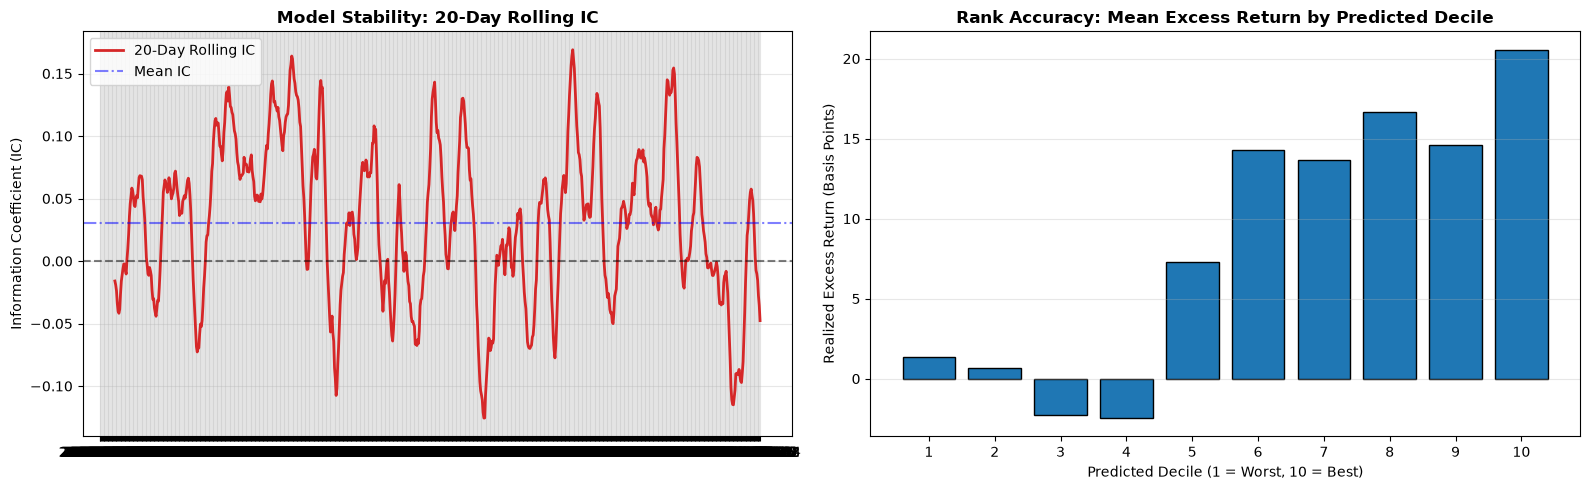

In [380]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#rolling Ic 20 days
axes[0].plot(daily_ic.index, rolling_ic, color='#d62728', linewidth=2, label='20-Day Rolling IC')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].axhline(daily_ic.mean(), color='blue', linestyle='-.', alpha=0.5, label='Mean IC')
axes[0].set_title('Model Stability: 20-Day Rolling IC', fontweight='bold')
axes[0].set_ylabel('Information Coefficient (IC)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# decile spread
bars = axes[1].bar(decile_spread.index, decile_spread.values, color='#1f77b4', edgecolor='black')
axes[1].set_title('Rank Accuracy: Mean Excess Return by Predicted Decile', fontweight='bold')
axes[1].set_xlabel('Predicted Decile (1 = Worst, 10 = Best)')
axes[1].set_ylabel('Realized Excess Return (Basis Points)')
axes[1].set_xticks(range(1, 11))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Portfolio Evaluation

In [389]:
# Strategy 1 - Portfolio ( Long only top 20 Equal Weight )

In [384]:
oos_df = df_nn_oos.copy()
oos_df = pd.merge(oos_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')

# Rebalance every 5 trading days 
unique_dates = sorted(oos_df['Date'].unique())
rebalance_dates = unique_dates[::5] 

portfolio_returns = []

# strategy - Buy Top 20 stocks by Neural Net score
for date in rebalance_dates:
    day_data = oos_df[oos_df['Date'] == date].copy()
    day_data = day_data.sort_values(by='Pred_Score', ascending=False)
    
    top_20 = day_data.head(20)
    port_ret = top_20['Fwd_Ret_5D'].mean()
    
    portfolio_returns.append({
        'Date': date,
        'Port_Ret_5D': port_ret
    })
    
port_df = pd.DataFrame(portfolio_returns)
port_df['Date'] = pd.to_datetime(port_df['Date'])
port_df.set_index('Date', inplace=True)
port_df['Equity_Curve'] = (1 + port_df['Port_Ret_5D']).cumprod()

In [595]:
from scipy.stats import skew, kurtosis

def evaluate_portfolio(port_df, return_col='Port_Ret_5D', holding_period=5):

    returns = port_df[return_col].dropna()
    equity_curve = (1 + returns).cumprod()
    
    # Time adjustments
    periods_per_year = 252 / holding_period
    years = len(returns) / periods_per_year
    
    # 1. Basic Return Metrics
    total_return = equity_curve.iloc[-1] - 1
    cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    
    # 2. Risk-Adjusted Returns (Assuming 0% risk-free rate for absolute return focus)
    sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)
    
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
    sortino = cagr / downside_vol if downside_vol != 0 else 0
    
    # 3. Drawdown Profile
    rolling_max = equity_curve.cummax()
    drawdowns = (equity_curve / rolling_max) - 1
    max_dd = drawdowns.min()
    
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    # Drawdown Duration (in holding periods, then converted to trading days)
    dd_groups = (drawdowns == 0).cumsum()
    dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).cumcount()
    max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0
    
    # 4. Tail Risk & Distribution
    hit_rate = (returns > 0).mean()
    var_95 = np.percentile(returns, 5) # Value at Risk (95% confidence)
    cvar_95 = returns[returns <= var_95].mean() # Conditional VaR (Expected Shortfall)
    ret_skew = skew(returns)
    ret_kurtosis = kurtosis(returns)
    
    metrics = {
        "Total Return": f"{total_return:.2%}",
        "CAGR": f"{cagr:.2%}",
        "Ann. Volatility": f"{ann_vol:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Max Drawdown": f"{max_dd:.2%}",
        "Max DD Duration": f"{max_dd_duration_days} Days",
        "Hit Rate": f"{hit_rate:.2%}",
        "Weekly VaR (95%)": f"{var_95:.2%}",
        "Weekly CVaR (95%)": f"{cvar_95:.2%}",
        "Skew": f"{ret_skew:.2f}",
        "Kurtosis": f"{ret_kurtosis:.2f}"
    }
    
    return pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

In [596]:
s1_metrics = evaluate_portfolio(port_df, return_col='Port_Ret_5D')

print(s1_metrics)

                      Value
Total Return         94.21%
CAGR                 22.63%
Ann. Volatility      17.39%
Sharpe Ratio           1.26
Sortino Ratio          2.30
Calmar Ratio           1.10
Max Drawdown        -20.63%
Max DD Duration    400 Days
Hit Rate             55.49%
Weekly VaR (95%)     -3.27%
Weekly CVaR (95%)    -4.40%
Skew                   0.36
Kurtosis               0.92


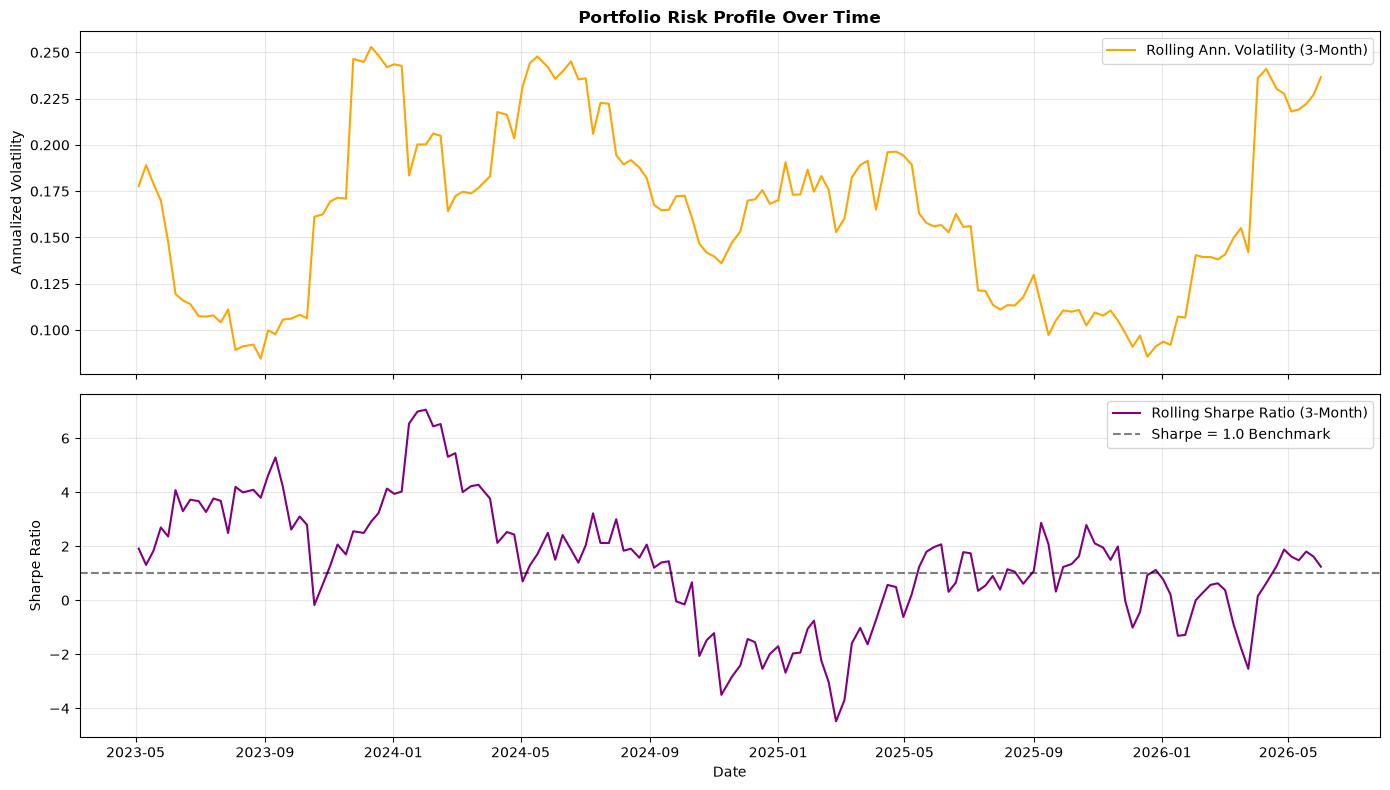

In [388]:
rolling_window = 12 
roll_ret = port_df['Port_Ret_5D'].rolling(rolling_window).mean() * (252/5)
roll_vol = port_df['Port_Ret_5D'].rolling(rolling_window).std() * np.sqrt(252/5)
roll_sharpe = roll_ret / roll_vol

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Rolling Volatility
axes[0].plot(port_df.index, roll_vol, color='orange', label='Rolling Ann. Volatility (3-Month)')
axes[0].set_title('Portfolio Risk Profile Over Time', fontweight='bold')
axes[0].set_ylabel('Annualized Volatility')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Rolling Sharpe
axes[1].plot(port_df.index, roll_sharpe, color='purple', label='Rolling Sharpe Ratio (3-Month)')
axes[1].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Sharpe = 1.0 Benchmark')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Portfolio construction ( with different Strategies)

### Strategy 1- Long Only Top 20 Equal Weight

In [392]:
s1_df = df_nn_oos.copy()
s1_df = pd.merge(s1_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')


# rebalance days ( here 5 )
unique_dates = sorted(s1_df['Date'].unique())
rebalance_dates = unique_dates[::5] 


s1_trades = []
s1_portfolio_returns = []

for date in rebalance_dates:
    day_data = s1_df[s1_df['Date'] == date].copy()
    
    day_data = day_data.sort_values(by='Pred_Score', ascending=False)
    
    top_20 = day_data.head(20).copy()
    
    top_20['Weight'] = 1.0 / len(top_20)
    
    port_ret = (top_20['Fwd_Ret_5D'] * top_20['Weight']).sum()
    
    s1_portfolio_returns.append({
        'Date': date,
        'Gross_Return': port_ret
    })
    
    top_20['Rebalance_Date'] = date
    s1_trades.append(top_20[['Rebalance_Date', 'Ticker', 'Weight', 'Pred_Score']])

In [393]:
# s1 dataframe 

In [394]:
s1_port_df = pd.DataFrame(s1_portfolio_returns)
s1_port_df['Date'] = pd.to_datetime(s1_port_df['Date'])
s1_port_df.set_index('Date', inplace=True)
s1_port_df['Equity_Curve'] = (1 + s1_port_df['Gross_Return']).cumprod()

s1_trade_history = pd.concat(s1_trades, ignore_index=True)

In [594]:
print("Complete Institutional Metrics for Strategy 1\n")

# 1. Base Return and Equity Curve Series
returns = s1_port_df['Gross_Return'].dropna()
equity_curve = (1 + returns).cumprod()

holding_period = 5  # H = 5 days
periods_per_year = 252 / holding_period
years = len(returns) / periods_per_year

# 2. Return & Volatility Metrics
total_return = equity_curve.iloc[-1] - 1
cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)

# 3. Risk-Adjusted Metrics (Sharpe & Sortino)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)
downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

# 4. Drawdown & Calmar Ratio
rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

# Drawdown Duration (in trading days)
dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

# 5. Hit Rate & Distribution Shape
hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)

# 6. Tail Risk: VaR and CVaR (95% Confidence)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

# 7. Turnover Calculation (Using s1_trade_history weights)
weight_matrix = s1_trade_history.pivot(index='Rebalance_Date', columns='Ticker', values='Weight').fillna(0.0)
turnover_series = weight_matrix.diff().abs().sum(axis=1) * 0.5
avg_turnover = turnover_series.mean()

# 8. Compile into a Professional Tear Sheet Table
s1_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
    "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
    "Return Skewness": f"{ret_skew:.2f}",
    "Return Kurtosis": f"{ret_kurt:.2f}",
    "Weekly VaR (95%)": f"{var_95:.2%}",
    "Weekly CVaR (95%)": f"{cvar_95:.2%}",
    "Average Period Turnover": f"{avg_turnover:.2%}"
}

s1_metrics_table = pd.DataFrame.from_dict(s1_full_metrics, orient='index', columns=['Strategy 1'])
print(s1_metrics_table.to_string())

Complete Institutional Metrics for Strategy 1

                                   Strategy 1
CAGR                                   22.63%
Annualized Volatility                  17.39%
Sharpe Ratio                             1.26
Sortino Ratio                            2.30
Calmar Ratio                             1.10
Max Drawdown                          -20.63%
Max Drawdown Duration        405 Trading Days
Hit Rate (Positive Periods)            55.49%
Return Skewness                          0.36
Return Kurtosis                          0.92
Weekly VaR (95%)                       -3.27%
Weekly CVaR (95%)                      -4.40%
Average Period Turnover                40.79%


In [416]:
# Strategy 1 Equity Curve vs Nifty 50

In [404]:
s1_equity_100 = s1_port_df['Equity_Curve'] * 100

nifty_dates = s1_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()

nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

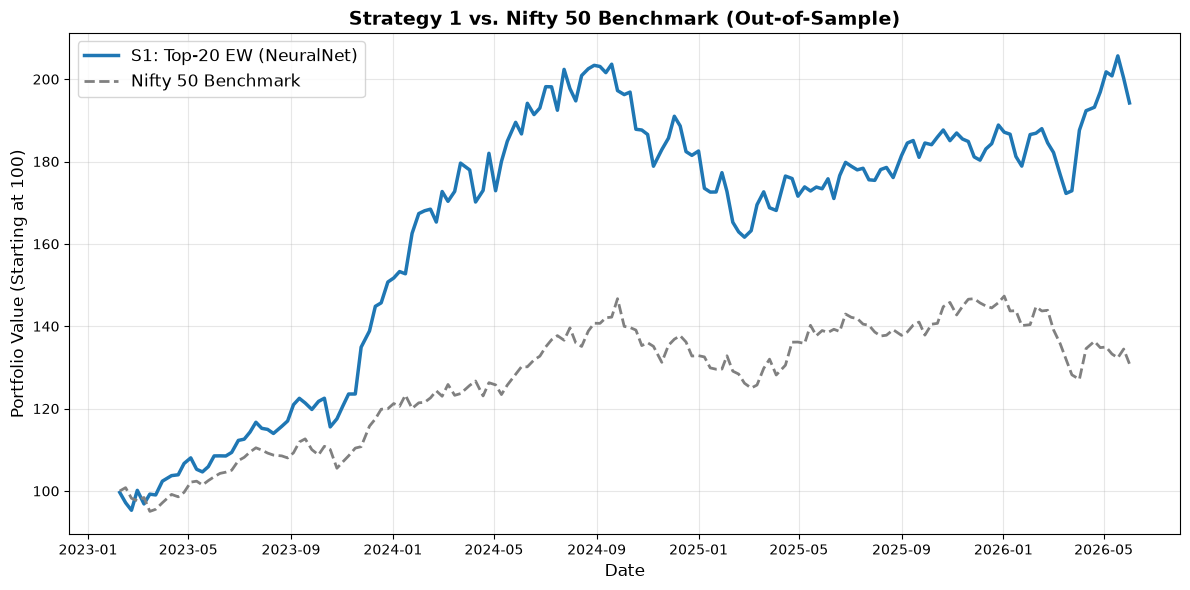

In [406]:
plt.figure(figsize=(12, 6))
plt.plot(s1_port_df.index, s1_equity_100, color='#1f77b4', linewidth=2.5, label='S1: Top-20 EW (NeuralNet)')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark')

plt.title('Strategy 1 vs. Nifty 50 Benchmark (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Strategy 2- Long Only (Top-Decile + Volatility Targeting)

Instead of top 10 or 20 stocks Now i will add all the stocks in top decile 
I will also also calculate the moving average of Annualised Volatility to limit the market Exposure

In [409]:
s2_df = df_nn_oos.copy()
s2_df = pd.merge(s2_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D', 'Nifty_Return']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s2_df['Date'].unique())
rebalance_dates = unique_dates[::5] # Rebalance every 5 days (H=5)

target_ann_vol = 0.15 # Target annualized volatility of 15%
holding_period = 5
periods_per_year = 252 / holding_period

s2_portfolio_returns = []
s2_trades = []

In [410]:
# calculating the unscaled Top-Decile returns to measure rolling volatility

In [411]:
raw_s2_returns = []
for date in rebalance_dates:
    day_data = s2_df[s2_df['Date'] == date].sort_values(by='Pred_Score', ascending=False)
    # taking top decile (top 10% of available liquid stocks on that day)
    top_decile_count = max(1, int(len(day_data) * 0.10))
    top_decile = day_data.head(top_decile_count).copy()
    top_decile['Weight'] = 1.0 / len(top_decile)
    
    port_ret = (top_decile['Fwd_Ret_5D'] * top_decile['Weight']).sum()
    raw_s2_returns.append({'Date': date, 'Return': port_ret})

raw_s2_df = pd.DataFrame(raw_s2_returns).set_index(pd.to_datetime([x['Date'] for x in raw_s2_returns]))

# calculating rolling annualized volatility
rolling_vol = raw_s2_df['Return'].rolling(window=6, min_periods=1).std() * np.sqrt(periods_per_year)

In [412]:
# applying volatility scaling factor

In [413]:
s2_scaled_returns = []
for i, date in enumerate(rebalance_dates):
    dt = pd.to_datetime(date)
    if i == 0 or rolling_vol.iloc[i] == 0 or np.isnan(rolling_vol.iloc[i]):
        scale_factor = 1.0
    else:
        past_vol = rolling_vol.iloc[i-1]
        scale_factor = target_ann_vol / past_vol if past_vol > 0 else 1.0
        scale_factor = np.clip(scale_factor, 0.2, 1.5)
        
    scaled_ret = raw_s2_df.loc[dt, 'Return'] * scale_factor
    s2_scaled_returns.append({'Date': date, 'Gross_Return': scaled_ret, 'Scale': scale_factor})

s2_port_df = pd.DataFrame(s2_scaled_returns)
s2_port_df['Date'] = pd.to_datetime(s2_port_df['Date'])
s2_port_df.set_index('Date', inplace=True)
s2_port_df['Equity_Curve'] = (1 + s2_port_df['Gross_Return']).cumprod()

In [592]:
print("Complete Institutional Metrics for Strategy 2\n") 

returns = s2_port_df['Gross_Return'].dropna()
equity_curve = s2_port_df['Equity_Curve']
years = len(returns) / periods_per_year

total_return = equity_curve.iloc[-1] - 1
cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

s2_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
    "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
    "Return Skewness": f"{ret_skew:.2f}",
    "Return Kurtosis": f"{ret_kurt:.2f}",
    "Weekly VaR (95%)": f"{var_95:.2%}",
    "Weekly CVaR (95%)": f"{cvar_95:.2%}"
}
print(pd.DataFrame.from_dict(s2_full_metrics, orient='index', columns=['Strategy 2']).to_string())

Complete Institutional Metrics for Strategy 2

                                   Strategy 2
CAGR                                   12.48%
Annualized Volatility                  19.44%
Sharpe Ratio                             0.70
Sortino Ratio                            1.11
Calmar Ratio                             0.43
Max Drawdown                          -28.74%
Max Drawdown Duration        460 Trading Days
Hit Rate (Positive Periods)            54.27%
Return Skewness                          0.86
Return Kurtosis                          3.90
Weekly VaR (95%)                       -3.58%
Weekly CVaR (95%)                      -5.00%


In [427]:
# Strategy 2 Equity Curve vs Nifty 50

In [418]:
s2_equity_100 = s2_port_df['Equity_Curve'] * 100

nifty_dates = s2_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

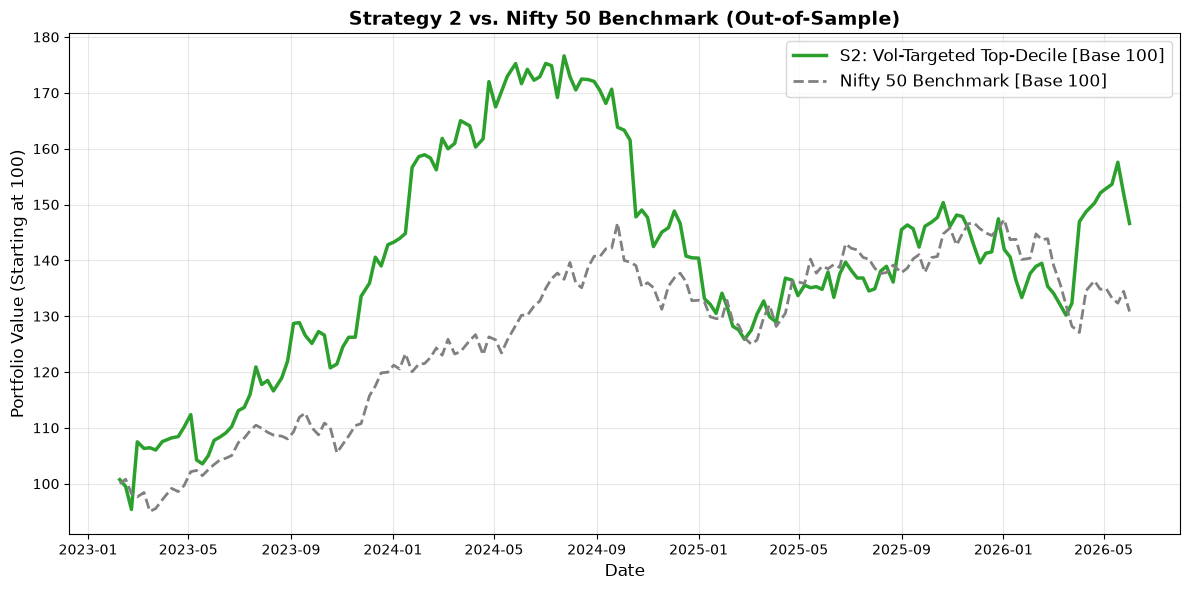

In [419]:
plt.figure(figsize=(12, 6))
plt.plot(s2_port_df.index, s2_equity_100, color='#2ca02c', linewidth=2.5, label='S2: Vol-Targeted Top-Decile [Base 100]')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')
plt.title('Strategy 2 vs. Nifty 50 Benchmark (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Strategy 3- Long-Only + Rolling Beta Hedge (Market-Neutral Alpha)

Since all the stocks have a positive beta with nifty 50. so if the market is crashing no matter what stocks we select it will be dragged down

So i will be hedging out that market sensitivity by shorting or scaling against the nifty ( proportional to rolling beta)

In [597]:
master_panel = master_panel.sort_values(by=['Ticker', 'Date'])
nifty_daily = master_panel[['Date', 'Nifty']].drop_duplicates().sort_values('Date')
nifty_daily['Fwd_Nifty_Ret_5D'] = nifty_daily['Nifty'].shift(-5) / nifty_daily['Nifty'] - 1

if 'Fwd_Nifty_Ret_5D' in master_panel.columns:
    master_panel.drop(columns=['Fwd_Nifty_Ret_5D'], inplace=True)
master_panel = pd.merge(master_panel, nifty_daily[['Date', 'Fwd_Nifty_Ret_5D']], on='Date', how='left')

s3_fixed_df = df_nn_oos.copy()
s3_fixed_df = pd.merge(s3_fixed_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D', 'Fwd_Nifty_Ret_5D']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s3_fixed_df['Date'].unique())
rebalance_dates = unique_dates[::5]

In [421]:
# generate unhedged top 20 portfolio returns and market returns for beta estimation

In [598]:
raw_s3_data = []
for date in rebalance_dates:
    day_data = s3_fixed_df[s3_fixed_df['Date'] == date].sort_values(by='Pred_Score', ascending=False)
    
    if day_data.empty or pd.isna(day_data['Fwd_Nifty_Ret_5D'].iloc[0]):
        continue
        
    top_20 = day_data.head(20).copy()
    port_ret = top_20['Fwd_Ret_5D'].mean()
    mkt_ret_5d = day_data['Fwd_Nifty_Ret_5D'].iloc[0]
    
    raw_s3_data.append({'Date': date, 'Port_Ret': port_ret, 'Mkt_Ret': mkt_ret_5d})

raw_s3_fixed_df = pd.DataFrame(raw_s3_data).set_index(pd.to_datetime([x['Date'] for x in raw_s3_data]))

In [424]:
# calculate rolling beta and apply dynamic market hedge

Beta = Covariance(Portfolio, Market) / Variance(Market) over a rolling 12-period window (approx 3 months)

In [599]:
window = 12
rolling_cov = raw_s3_fixed_df['Port_Ret'].rolling(window=window, min_periods=3).cov(raw_s3_fixed_df['Mkt_Ret'])
rolling_var = raw_s3_fixed_df['Mkt_Ret'].rolling(window=window, min_periods=3).var()
rolling_beta = (rolling_cov / rolling_var).fillna(1.0).clip(0.2, 2.0)

s3_fixed_returns = []
for i, date in enumerate(rebalance_dates):
    dt = pd.to_datetime(date)
    if dt not in raw_s3_fixed_df.index:
        continue
        
    p_ret = raw_s3_fixed_df.loc[dt, 'Port_Ret']
    m_ret = raw_s3_fixed_df.loc[dt, 'Mkt_Ret']
    beta = rolling_beta.iloc[i-1] if i > 0 else 1.0
    
    hedged_ret = p_ret - (beta * m_ret)
    s3_fixed_returns.append({'Date': date, 'Gross_Return': hedged_ret})

In [604]:
s3_fixed_port = pd.DataFrame(s3_fixed_returns).set_index('Date')['Gross_Return']
s3_metrics = get_performance_metrics(s3_fixed_port, holding_period=5)

In [605]:
print("Complete Institutional Metrics for Strategy 3\n")  

returns = s3_port_df['Gross_Return'].dropna()
equity_curve = s3_port_df['Equity_Curve']
years = len(returns) / periods_per_year

total_return = equity_curve.iloc[-1] - 1
cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

s3_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
    "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
    "Return Skewness": f"{ret_skew:.2f}",
    "Return Kurtosis": f"{ret_kurt:.2f}",
    "Weekly VaR (95%)": f"{var_95:.2%}",
    "Weekly CVaR (95%)": f"{cvar_95:.2%}"
}

print(pd.DataFrame.from_dict(s3_full_metrics, orient='index', columns=['Strategy 3']).to_string())

Complete Institutional Metrics for Strategy 3

                                   Strategy 3
CAGR                                   15.37%
Annualized Volatility                  17.74%
Sharpe Ratio                             0.90
Sortino Ratio                            1.37
Calmar Ratio                             0.61
Max Drawdown                          -25.36%
Max Drawdown Duration        500 Trading Days
Hit Rate (Positive Periods)            57.93%
Return Skewness                          0.11
Return Kurtosis                          1.34
Weekly VaR (95%)                       -3.29%
Weekly CVaR (95%)                      -4.98%


In [502]:
# Strategy 3 Equity Curve vs Nifty 50

In [431]:
s3_equity_100 = s3_port_df['Equity_Curve'] * 100

nifty_dates = s3_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

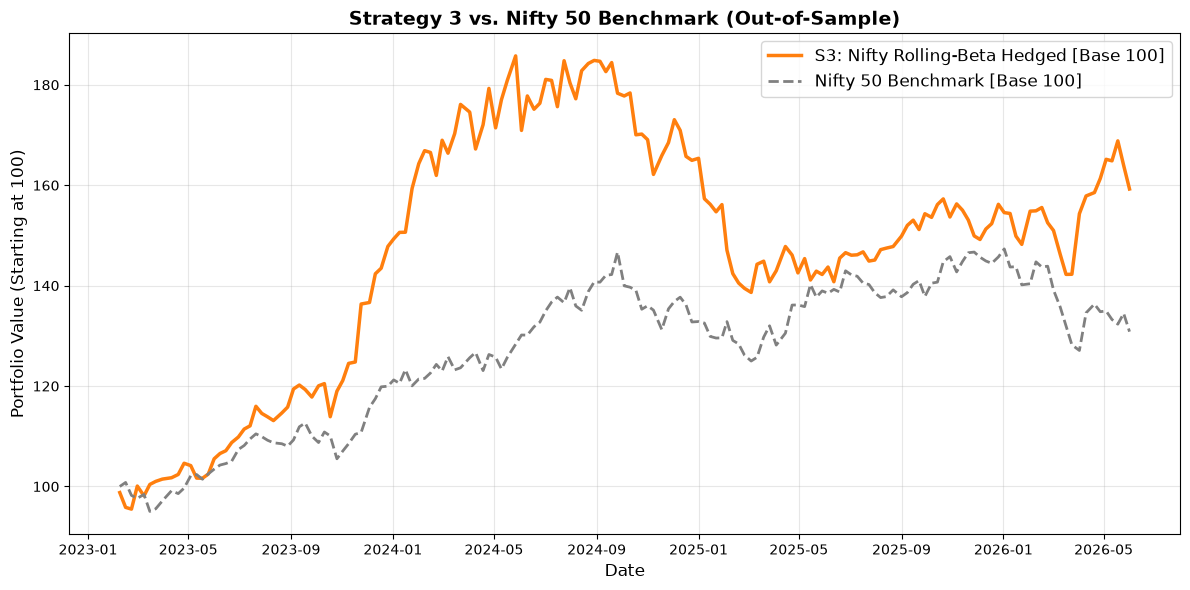

In [432]:
plt.figure(figsize=(12, 6))
plt.plot(s3_port_df.index, s3_equity_100, color='#ff7f0e', linewidth=2.5, label='S3: Nifty Rolling-Beta Hedged [Base 100]')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')
plt.title('Strategy 3 vs. Nifty 50 Benchmark (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Strategy 4- Longâ€“Short Decile Spread (research strategy)

long top decile and short bottom decile

In [440]:
s4_df = df_nn_oos.copy()
s4_df = pd.merge(s4_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D', 'Nifty_Return']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s4_df['Date'].unique())
rebalance_dates = unique_dates[::5] # Rebalance every 5 days (H=5)

holding_period = 5
periods_per_year = 252 / holding_period

s4_portfolio_returns = []

In [441]:
# long top decile and short bottom decile

In [442]:
for date in rebalance_dates:
    day_data = s4_df[s4_df['Date'] == date].sort_values(by='Pred_Score', ascending=False)
    
    decile_count = max(1, int(len(day_data) * 0.10))
    
    # Top Decile
    top_decile = day_data.head(decile_count)
    long_ret = top_decile['Fwd_Ret_5D'].mean()
    
    # Bottom Decile
    bottom_decile = day_data.tail(decile_count)
    short_ret = bottom_decile['Fwd_Ret_5D'].mean()
    
    # 50% capital long and 50% capital short
    spread_ret = long_ret - short_ret
    
    s4_portfolio_returns.append({
        'Date': date,
        'Gross_Return': spread_ret,
        'Long_Ret': long_ret,
        'Short_Ret': short_ret
    })

s4_port_df = pd.DataFrame(s4_portfolio_returns)
s4_port_df['Date'] = pd.to_datetime(s4_port_df['Date'])
s4_port_df.set_index('Date', inplace=True)
s4_port_df['Equity_Curve'] = (1 + s4_port_df['Gross_Return']).cumprod()

In [590]:
print("Complete Institutional Metrics for Strategy 4\n")  

returns = s4_port_df['Gross_Return'].dropna()
equity_curve = s4_port_df['Equity_Curve']
years = len(returns) / periods_per_year

total_return = equity_curve.iloc[-1] - 1
cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

s4_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
    "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
    "Return Skewness": f"{ret_skew:.2f}",
    "Return Kurtosis": f"{ret_kurt:.2f}",
    "Weekly VaR (95%)": f"{var_95:.2%}",
    "Weekly CVaR (95%)": f"{cvar_95:.2%}"
}

print(pd.DataFrame.from_dict(s4_full_metrics, orient='index', columns=['Strategy 4']).to_string())


Complete Institutional Metrics for Strategy 4

                                   Strategy 4
CAGR                                    4.89%
Annualized Volatility                  18.51%
Sharpe Ratio                             0.35
Sortino Ratio                            0.46
Calmar Ratio                             0.35
Max Drawdown                          -14.02%
Max Drawdown Duration        215 Trading Days
Hit Rate (Positive Periods)            49.39%
Return Skewness                          0.54
Return Kurtosis                          1.85
Weekly VaR (95%)                       -3.60%
Weekly CVaR (95%)                      -5.08%


In [445]:
# Strategy 4 Equity Curve vs Nifty 50

In [446]:
s4_equity_100 = s4_port_df['Equity_Curve'] * 100

nifty_dates = s4_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

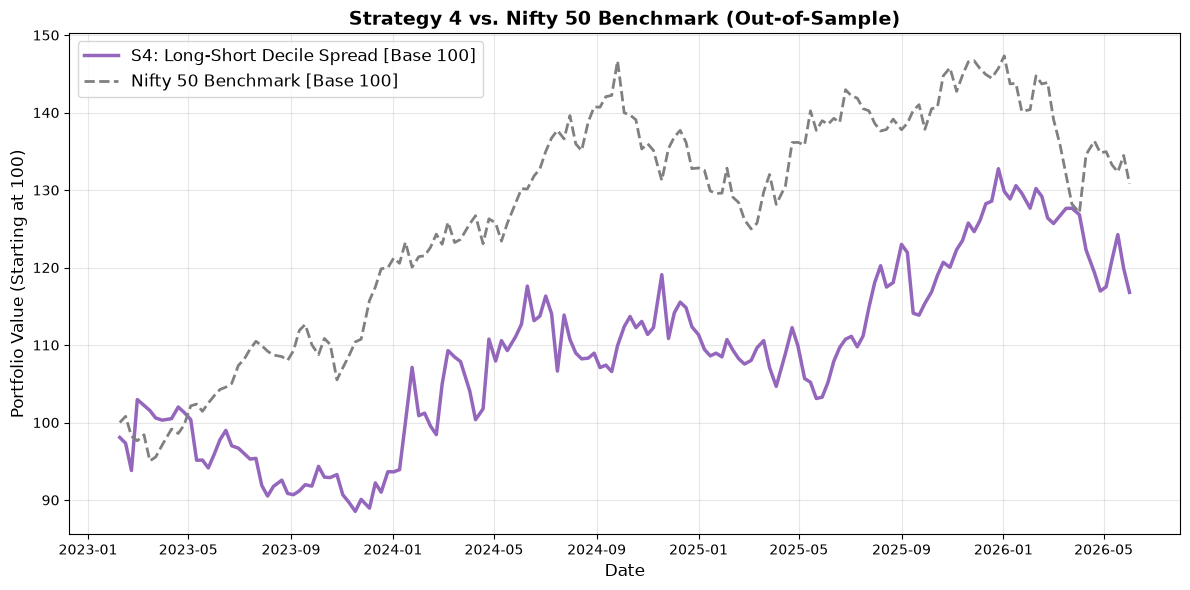

In [447]:
plt.figure(figsize=(12, 6))
plt.plot(s4_port_df.index, s4_equity_100, color='#9467bd', linewidth=2.5, label='S4: Long-Short Decile Spread [Base 100]')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')
plt.title('Strategy 4 vs. Nifty 50 Benchmark (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Strategy 4.1- Longâ€“Short Top-10 Spread (research strategy)

Long on top 10 and short on bottom 10

In [493]:
s41_df = df_nn_oos.copy()
s41_df = pd.merge(s41_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D', 'Nifty_Return']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s41_df['Date'].unique())
rebalance_dates = unique_dates[::5] # Rebalance every 5 days (H=5)

holding_period = 5
periods_per_year = 252 / holding_period

s41_portfolio_returns = []

In [494]:
# Long Top 10, Short Bottom 10

In [495]:
for date in rebalance_dates:
    day_data = s41_df[s41_df['Date'] == date].sort_values(by='Pred_Score', ascending=False)
    
    # Top 10 
    top_10 = day_data.head(10)
    long_ret = top_10['Fwd_Ret_5D'].mean()
    
    # Bottom 10
    bottom_10 = day_data.tail(10)
    short_ret = bottom_10['Fwd_Ret_5D'].mean()

    spread_ret = long_ret - short_ret
    
    s41_portfolio_returns.append({
        'Date': date,
        'Gross_Return': spread_ret,
        'Long_Ret': long_ret,
        'Short_Ret': short_ret
    })

s41_port_df = pd.DataFrame(s41_portfolio_returns)
s41_port_df['Date'] = pd.to_datetime(s41_port_df['Date'])
s41_port_df.set_index('Date', inplace=True)
s41_port_df['Equity_Curve'] = (1 + s41_port_df['Gross_Return']).cumprod()

In [589]:
print("Complete Institutional Metrics for Strategy 4.1\n")

returns = s41_port_df['Gross_Return'].dropna()
equity_curve = s41_port_df['Equity_Curve']
years = len(returns) / periods_per_year

total_return = equity_curve.iloc[-1] - 1
cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

s41_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
    "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
    "Return Skewness": f"{ret_skew:.2f}",
    "Return Kurtosis": f"{ret_kurt:.2f}",
    "Weekly VaR (95%)": f"{var_95:.2%}",
    "Weekly CVaR (95%)": f"{cvar_95:.2%}"
}

print(pd.DataFrame.from_dict(s41_full_metrics, orient='index', columns=['Strategy 4.1']).to_string())

Complete Institutional Metrics for Strategy 4.1

                                 Strategy 4.1
CAGR                                    8.22%
Annualized Volatility                  17.77%
Sharpe Ratio                             0.53
Sortino Ratio                            0.81
Calmar Ratio                             0.67
Max Drawdown                          -12.30%
Max Drawdown Duration        180 Trading Days
Hit Rate (Positive Periods)            50.61%
Return Skewness                          0.61
Return Kurtosis                          1.85
Weekly VaR (95%)                       -3.96%
Weekly CVaR (95%)                      -4.79%


In [505]:
# Strategy 4.1 Equity Curve vs Nifty 50

In [506]:
s41_equity_100 = s41_port_df['Equity_Curve'] * 100

nifty_dates = s41_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

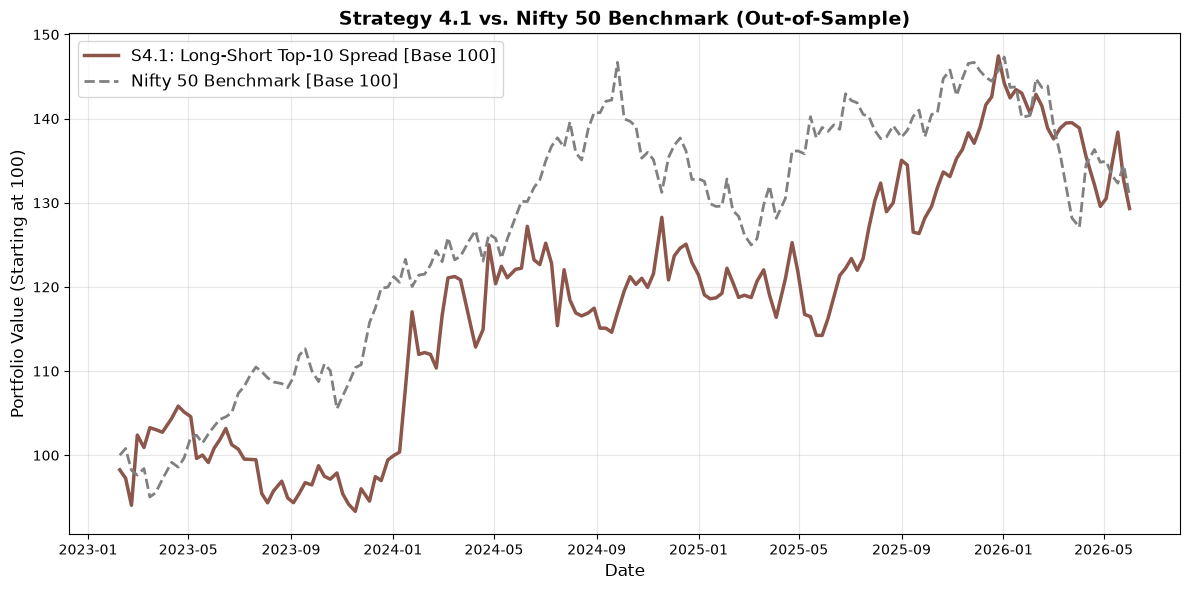

In [507]:
plt.figure(figsize=(12, 6))
plt.plot(s41_port_df.index, s41_equity_100, color='#8c564b', linewidth=2.5, label='S4.1: Long-Short Top-10 Spread [Base 100]')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')
plt.title('Strategy 4.1 vs. Nifty 50 Benchmark (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Few Advance Strategies

### Strategy 5- Meta-Labeled Strategy

I will train a LighGBM model on every top 20 trade the neural network recommends over time ( the MLP layer ). 

the lightGBM will be trained on a rolling historic window to predict the profitable days

then we will execute only when the Meta Model gives a probability more than 50%

In [524]:
s5_df = df_nn_oos.copy()
# adding volatility, RSI, and PCR
s5_df = pd.merge(s5_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D', 'Nifty_Return', 'Vol_20D', 'RSI_14', 'Delta_PCR']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s5_df['Date'].unique())
rebalance_dates = unique_dates[::5]

holding_period = 5
periods_per_year = 252 / holding_period

# top 20 
candidate_trades = []
for date in rebalance_dates:
    day_data = s5_df[s5_df['Date'] == date].sort_values(by='Pred_Score', ascending=False)
    candidate_trades.append(day_data.head(20).copy())

candidates_df = pd.concat(candidate_trades, ignore_index=True)

# meta model target 
candidates_df['Meta_Target'] = (candidates_df['Fwd_Ret_5D'] > 0).astype(int)
meta_features = ['Pred_Score', 'Vol_20D', 'RSI_14', 'Delta_PCR']

s5_portfolio_returns = []
INITIAL_TRAIN_PERIODS = 12 # need 3 months of trade histroy before the meta model start prediucting

In [525]:
print("training rolling Meta model")
for i, date in enumerate(rebalance_dates):
    current_candidates = candidates_df[candidates_df['Date'] == date].copy()
    
    if i < INITIAL_TRAIN_PERIODS:
        # Not enough history yet; accept all Top 20 trades (acts exactly like S1)
        port_ret = current_candidates['Fwd_Ret_5D'].mean()
    else:
        # Strict Out-of-Sample: Train Meta-Model only on past trades
        past_data = candidates_df[candidates_df['Date'] < date]
        
        meta_model = lgb.LGBMClassifier(
            n_estimators=40, max_depth=3, learning_rate=0.05, 
            verbosity=-1, random_state=42
        )
        meta_model.fit(past_data[meta_features], past_data['Meta_Target'])
        
        # Predict probability of success for today's Top 20 candidates
        current_candidates['Meta_Prob'] = meta_model.predict_proba(current_candidates[meta_features])[:, 1]
        
        # THE META-FILTER: Only execute trades with > 50% probability of success
        approved_trades = current_candidates[current_candidates['Meta_Prob'] > 0.50]
        
        if len(approved_trades) > 0:
            port_ret = approved_trades['Fwd_Ret_5D'].mean() # Equal weight the survivors
        else:
            port_ret = 0.0 # Vetoed all trades. Hold cash for the week.
            
    s5_portfolio_returns.append({'Date': date, 'Gross_Return': port_ret})

s5_port_df = pd.DataFrame(s5_portfolio_returns)
s5_port_df['Date'] = pd.to_datetime(s5_port_df['Date'])
s5_port_df.set_index('Date', inplace=True)
s5_port_df['Equity_Curve'] = (1 + s5_port_df['Gross_Return']).cumprod()

training rolling Meta model


In [588]:
print("Complete Institutional Metrics for Strategy 5\n")

returns = s5_port_df['Gross_Return'].dropna()
equity_curve = s5_port_df['Equity_Curve']
years = len(returns) / periods_per_year

total_return = equity_curve.iloc[-1] - 1
cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

s5_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
    "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
    "Return Skewness": f"{ret_skew:.2f}",
    "Return Kurtosis": f"{ret_kurt:.2f}",
    "Weekly VaR (95%)": f"{var_95:.2%}",
    "Weekly CVaR (95%)": f"{cvar_95:.2%}"
}

print("\n=== STRATEGY 5 (META-LABELED AFML): TEAR SHEET ===")
print(pd.DataFrame.from_dict(s5_full_metrics, orient='index', columns=['Strategy 5']).to_string())
print("-" * 55)

Complete Institutional Metrics for Strategy 5


=== STRATEGY 5 (META-LABELED AFML): TEAR SHEET ===
                                   Strategy 5
CAGR                                   20.23%
Annualized Volatility                  17.57%
Sharpe Ratio                             1.14
Sortino Ratio                            1.96
Calmar Ratio                             0.83
Max Drawdown                          -24.49%
Max Drawdown Duration        405 Trading Days
Hit Rate (Positive Periods)            55.49%
Return Skewness                          0.32
Return Kurtosis                          0.99
Weekly VaR (95%)                       -3.30%
Weekly CVaR (95%)                      -4.59%
-------------------------------------------------------


In [540]:
# Strategy 5 Equity Curve vs Nifty 50

In [528]:
s5_equity_100 = s5_port_df['Equity_Curve'] * 100

nifty_dates = s5_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

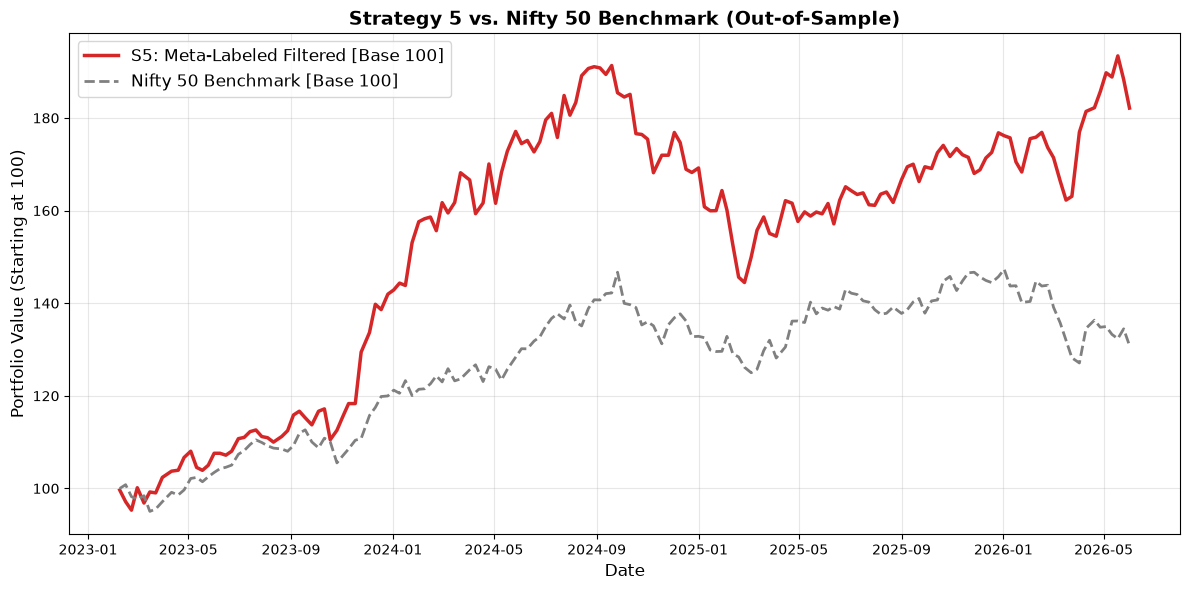

In [529]:
plt.figure(figsize=(12, 6))
plt.plot(s5_port_df.index, s5_equity_100, color='#d62728', linewidth=2.5, label='S5: Meta-Labeled Filtered [Base 100]')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')
plt.title('Strategy 5 vs. Nifty 50 Benchmark (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Strategy 6- Option Chain based Execution of Strategy 1 ( using PCR + OI )

only run S1 when regime is favorable (PCR trend + OI conditions)

In [554]:
s6_df = df_nn_oos.copy()
s6_df = pd.merge(s6_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D', 'Nifty_Return', 'Delta_PCR']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s6_df['Date'].unique())
rebalance_dates = unique_dates[::5] # Rebalance every 5 days (H=5)

holding_period = 5
periods_per_year = 252 / holding_period

s6_portfolio_returns = []

In [555]:
# execution loop option chain based 

In [556]:
for date in rebalance_dates:
    day_data = s6_df[s6_df['Date'] == date].sort_values(by='Pred_Score', ascending=False)
    
    current_pcr_delta = day_data['Delta_PCR'].iloc[0]
    is_regime_favorable = current_pcr_delta > -0.05 
    
    if is_regime_favorable:
        top_20 = day_data.head(20)
        port_ret = top_20['Fwd_Ret_5D'].mean()
    else:
        port_ret = 0.0
        
    s6_portfolio_returns.append({
        'Date': date,
        'Gross_Return': port_ret,
        'Regime_Favorable': is_regime_favorable
    })

s6_port_df = pd.DataFrame(s6_portfolio_returns)
s6_port_df['Date'] = pd.to_datetime(s6_port_df['Date'])
s6_port_df.set_index('Date', inplace=True)
s6_port_df['Equity_Curve'] = (1 + s6_port_df['Gross_Return']).cumprod()

In [584]:
print("Complete Institutional Metrics for Strategy 6\n") 

returns = s6_port_df['Gross_Return'].dropna()
equity_curve = s6_port_df['Equity_Curve']
years = len(returns) / periods_per_year

total_return = equity_curve.iloc[-1] - 1
cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

# how often sit in cash
time_in_market = s6_port_df['Regime_Favorable'].mean()

s6_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Time in Market": f"{time_in_market:.2%}",
    "Weekly VaR (95%)": f"{var_95:.2%}"
}
print(pd.DataFrame.from_dict(s6_full_metrics, orient='index', columns=['Strategy 6 (Gross)']).to_string())


Complete Institutional Metrics for Strategy 6

                      Strategy 6 (Gross)
CAGR                               8.74%
Annualized Volatility             13.14%
Sharpe Ratio                        0.70
Sortino Ratio                       0.85
Calmar Ratio                        0.62
Max Drawdown                     -14.03%
Time in Market                    59.76%
Weekly VaR (95%)                  -2.85%


In [585]:
# Strategy 6 - Equity Curve vs Nifty 50

In [586]:
s6_equity_100 = s6_port_df['Equity_Curve'] * 100

nifty_dates = s6_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

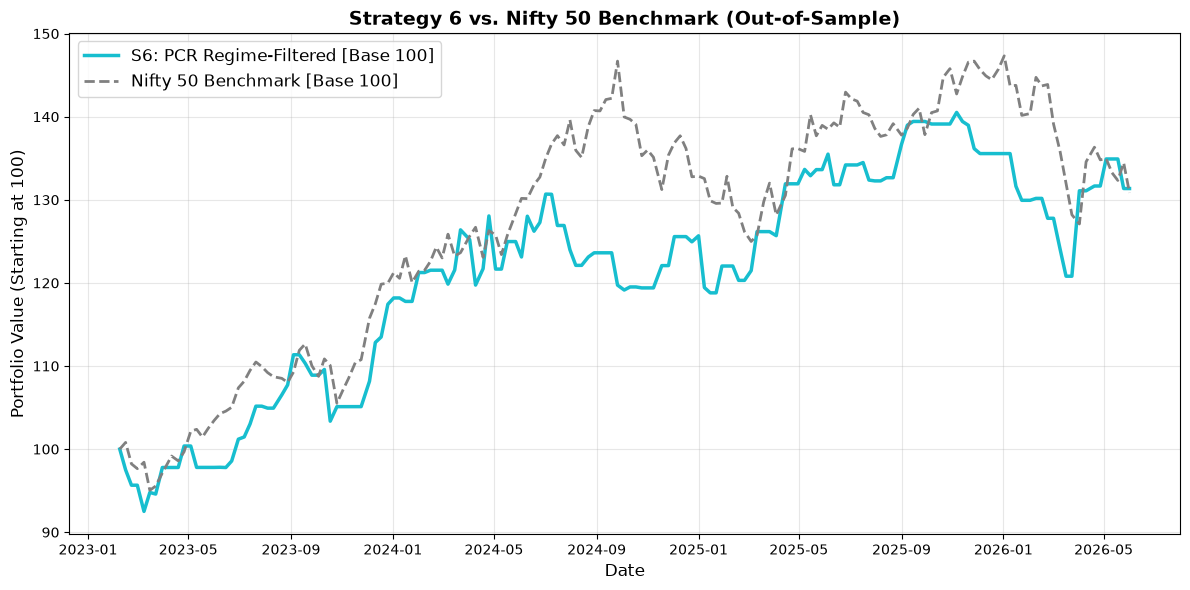

In [587]:
plt.figure(figsize=(12, 6))
plt.plot(s6_port_df.index, s6_equity_100, color='#17becf', linewidth=2.5, label='S6: PCR Regime-Filtered [Base 100]')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')
plt.title('Strategy 6 vs. Nifty 50 Benchmark (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Strategy 7- Convex Optimization (The Markowitz Model)

until now i was using equal weight to all the stocks in the portfolio. means i used to allocate equal capital to all the stocks in the portfolio

But S7 uses convex mathematical optimization to find the best portfolio weights on every rebalance date.

In [571]:
if 'Daily_Ret' not in master_panel.columns:
    master_panel = master_panel.sort_values(by=['Ticker', 'Date'])
    master_panel['Daily_Ret'] = master_panel.groupby('Ticker')['Close'].pct_change()

daily_returns_pivot = master_panel.pivot(index='Date', columns='Ticker', values='Daily_Ret').fillna(0)

RISK_AVERSION = 5.0      # Heavy penalty on historical volatility
MAX_WEIGHT = 0.10        # Max 10% allocation per stock to force diversification
holding_period = 5
periods_per_year = 252 / holding_period

s7_df = df_nn_oos.copy()
s7_df = pd.merge(s7_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s7_df['Date'].unique())
rebalance_dates = unique_dates[::5] 

s7_portfolio_returns = []

In [572]:
# optimization Loop

In [573]:
import cvxpy as cp

for date in rebalance_dates:
    day_data = s7_df[s7_df['Date'] == date].dropna(subset=['Pred_Score', 'Fwd_Ret_5D'])
    
    if day_data.empty:
        continue
        
    candidates = day_data.sort_values(by='Pred_Score', ascending=False).head(30)
    tickers = candidates['Ticker'].values
    n_assets = len(tickers)

    raw_alpha = candidates['Pred_Score'].values
    alpha = (raw_alpha - np.mean(raw_alpha)) / (np.std(raw_alpha) + 1e-8)
    
    hist_returns = daily_returns_pivot.loc[:date].iloc[-60:][tickers]
    cov_matrix = hist_returns.cov().values * 252 # Annualize
    cov_matrix += np.eye(n_assets) * 1e-6 # Add tiny constant to diagonal to ensure PSD matrix

    # cvxpy optimization
    w = cp.Variable(n_assets)
    portfolio_alpha = alpha.T @ w
    portfolio_variance = cp.quad_form(w, cov_matrix)

    # maximize alpha
    objective = cp.Maximize(portfolio_alpha - (RISK_AVERSION * portfolio_variance))
    
    constraints = [
        cp.sum(w) == 1,       # Fully invested
        w >= 0,               # Long only
        w <= MAX_WEIGHT       # Concentration limit
    ]
    
    prob = cp.Problem(objective, constraints)
    
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
        optimal_weights = w.value
        if optimal_weights is None:
            optimal_weights = np.ones(n_assets) / n_assets
        optimal_weights = np.clip(optimal_weights, 0, 1)
        optimal_weights /= np.sum(optimal_weights) 
    except Exception as e:
        # Fallback to equal weight on math convergence error
        optimal_weights = np.ones(n_assets) / n_assets
    
    # Calculate gross return based on optimal weights
    gross_ret = np.sum(optimal_weights * candidates['Fwd_Ret_5D'].values)
    s7_portfolio_returns.append({'Date': date, 'Gross_Return': gross_ret})

In [580]:
print("Complete Institutional Metrics for Strategy 7\n") 

s7_port_df = pd.DataFrame(s7_portfolio_returns)
s7_port_df['Date'] = pd.to_datetime(s7_port_df['Date'])
s7_port_df.set_index('Date', inplace=True)
s7_port_df['Equity_Curve'] = (1 + s7_port_df['Gross_Return']).cumprod()

returns = s7_port_df['Gross_Return'].dropna()
equity_curve = s7_port_df['Equity_Curve']
years = len(returns) / periods_per_year

cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1
ann_vol = returns.std() * np.sqrt(periods_per_year)
sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

downside_returns = returns[returns < 0]
downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
sortino = cagr / downside_vol if downside_vol != 0 else 0

rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else 0

dd_groups = (drawdowns == 0).cumsum()
dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0

hit_rate = (returns > 0).mean()
ret_skew = skew(returns)
ret_kurt = kurtosis(returns)
var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

s7_full_metrics = {
    "CAGR": f"{cagr:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Calmar Ratio": f"{calmar:.2f}",
    "Max Drawdown": f"{max_dd:.2%}",
    "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
    "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
    "Return Skewness": f"{ret_skew:.2f}",
    "Return Kurtosis": f"{ret_kurt:.2f}",
    "Weekly VaR (95%)": f"{var_95:.2%}",
    "Weekly CVaR (95%)": f"{cvar_95:.2%}"
}
print(pd.DataFrame.from_dict(s7_full_metrics, orient='index', columns=['Strategy 7']).to_string())

Complete Institutional Metrics for Strategy 7

                                   Strategy 7
CAGR                                   21.50%
Annualized Volatility                  16.43%
Sharpe Ratio                             1.27
Sortino Ratio                            2.35
Calmar Ratio                             1.10
Max Drawdown                          -19.58%
Max Drawdown Duration        420 Trading Days
Hit Rate (Positive Periods)            55.49%
Return Skewness                          0.31
Return Kurtosis                          0.58
Weekly VaR (95%)                       -3.46%
Weekly CVaR (95%)                      -4.00%


In [581]:
# Strategy 6 - Equity Curve vs Nifty 50

In [582]:
s7_equity_100 = s7_port_df['Equity_Curve'] * 100

nifty_dates = s7_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100

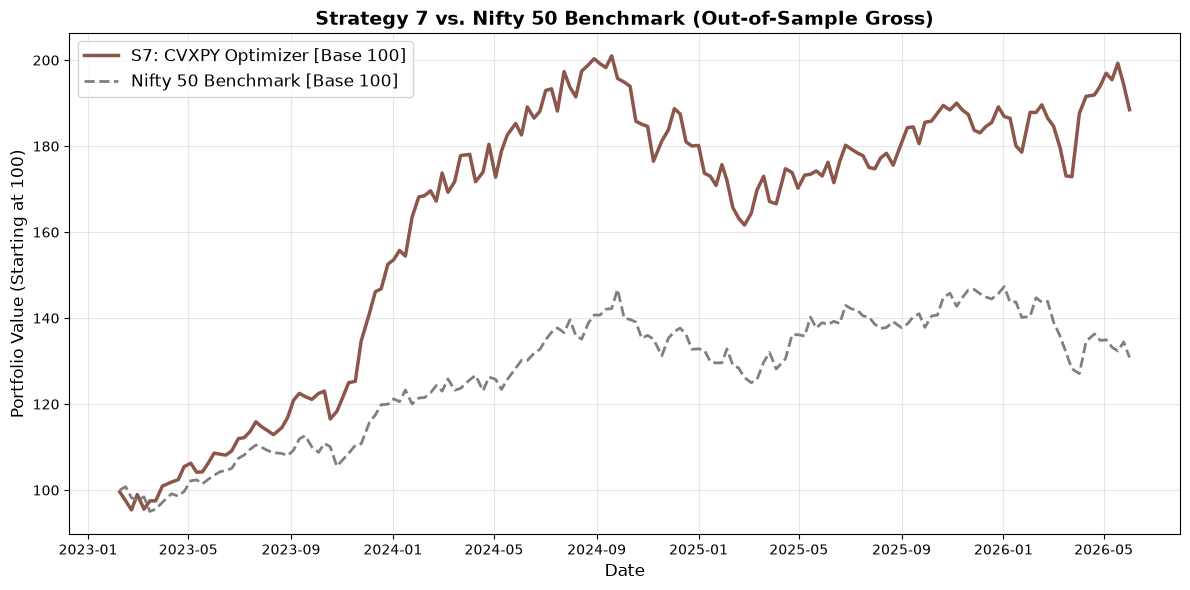

In [583]:
plt.figure(figsize=(12, 6))
plt.plot(s7_port_df.index, s7_equity_100, color='#8c564b', linewidth=2.5, label='S7: CVXPY Optimizer [Base 100]')
plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')
plt.title('Strategy 7 vs. Nifty 50 Benchmark (Out-of-Sample Gross)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Strategy Optimization

Will Try to Optimize and Maximize the returns on the winner strategies (S1 and S7) without overfitting

## 1) Tuning Holding Period and rebalance Frequency

In [611]:
K_TARGET = 20
HOLDING_PERIODS = [5, 10, 20]

master_panel = master_panel.sort_values(by=['Ticker', 'Date'])
for H in [10, 20]:
    col = f'Fwd_Ret_{H}D'
    if col not in master_panel.columns:
        master_panel[col] = master_panel.groupby('Ticker')['Close'].shift(-H) / master_panel['Close'] - 1

In [613]:
comparison_results = [] 

for H in HOLDING_PERIODS:
    print(f"Evaluating Strategy 1: H = {H} Days...")
    ret_col = f'Fwd_Ret_{H}D'
    
    h_df = df_nn_oos.copy()
    h_df = pd.merge(h_df, master_panel[['Date', 'Ticker', ret_col]], on=['Date', 'Ticker'], how='left')
    
    unique_dates = sorted(h_df['Date'].unique())
    rebalance_dates = unique_dates[::H] 
    
    portfolio_records = []
    prev_weights = pd.Series(dtype=float)
    
    for date in rebalance_dates:
        day_data = h_df[h_df['Date'] == date].dropna(subset=['Pred_Score', ret_col])
        if day_data.empty:
            continue
            
        day_data = day_data.sort_values(by='Pred_Score', ascending=False)
        top_basket = day_data.head(K_TARGET)['Ticker']
        
        current_weights = pd.Series(0.0, index=master_panel['Ticker'].unique())
        if len(top_basket) > 0:
            current_weights[top_basket] = 1.0 / len(top_basket)
            gross_ret = day_data.head(K_TARGET)[ret_col].mean()
        else:
            gross_ret = 0.0
            
        if prev_weights.empty:
            turnover = current_weights.abs().sum()
        else:
            turnover = (current_weights - prev_weights).abs().sum() / 2.0
            
        portfolio_records.append({
            'Date': date,
            'Gross_Return': gross_ret,
            'Turnover': turnover
        })
        
        prev_weights = current_weights.copy()
        
    res_df = pd.DataFrame(portfolio_records).set_index('Date')
    gross_returns = res_df['Gross_Return'].dropna()
    if len(gross_returns) == 0:
        continue
        
    equity_curve = (1 + gross_returns).cumprod()
    periods_per_year = 252 / H
    years = len(gross_returns) / periods_per_year
    
    gross_cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1 if years > 0 else 0
    gross_vol = gross_returns.std() * np.sqrt(periods_per_year)
    
    gross_sharpe = (gross_returns.mean() / (gross_returns.std() + 1e-12)) * np.sqrt(periods_per_year)
    avg_turnover = res_df['Turnover'].mean()
    
    comparison_results.append({
        'Holding Period (H)': f"{H} Days",
        'Rebalances / Year': int(periods_per_year),
        'Avg Period Turnover': f"{avg_turnover:.2%}",
        'Gross CAGR': f"{gross_cagr:.2%}",
        'Gross Ann. Vol': f"{gross_vol:.2%}",
        'Gross Sharpe Ratio': round(gross_sharpe, 2)
    })

comparison_df = pd.DataFrame(comparison_results).set_index('Holding Period (H)')
print(comparison_df.to_string())

Evaluating Strategy 1: H = 5 Days...
Evaluating Strategy 1: H = 10 Days...
Evaluating Strategy 1: H = 20 Days...
                    Rebalances / Year Avg Period Turnover Gross CAGR Gross Ann. Vol  Gross Sharpe Ratio
Holding Period (H)                                                                                     
5 Days                             50              41.40%     24.12%         16.51%                1.39
10 Days                            25              50.37%     20.22%         16.74%                1.19
20 Days                            12              58.29%     15.92%         12.90%                1.21


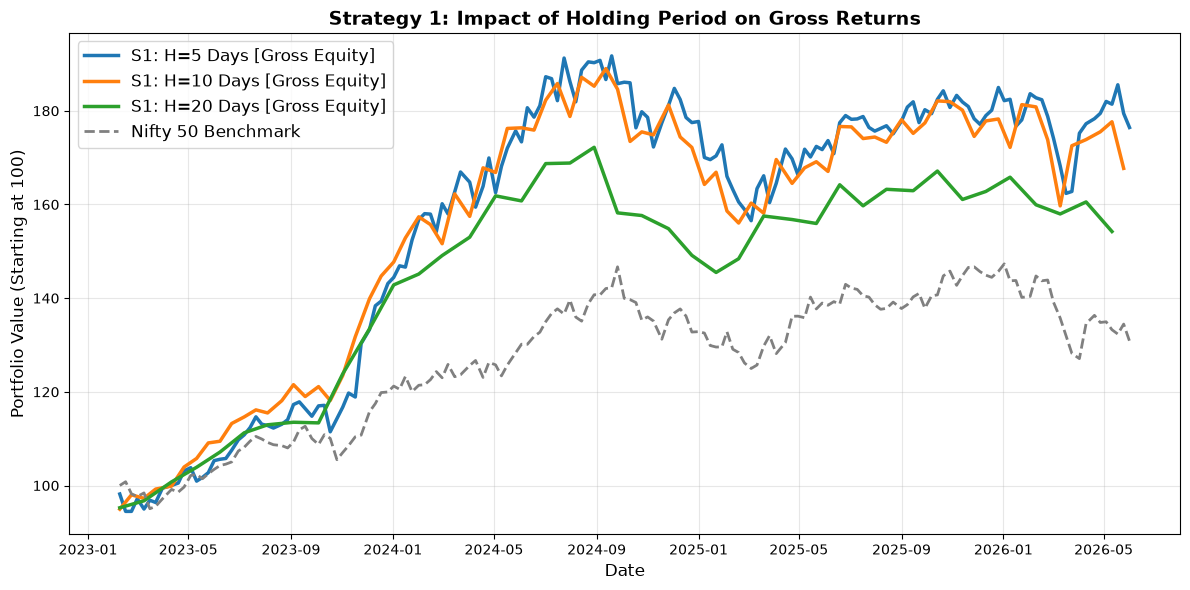

In [619]:
plt.figure(figsize=(12, 6))
colors = {5: '#1f77b4', 10: '#ff7f0e', 20: '#2ca02c'}

for H, curve in equity_curves.items():
    plt.plot(curve.index, curve * 100, color=colors.get(H, 'black'), linewidth=2.5, label=f'S1: H={H} Days [Gross Equity]')

if 5 in equity_curves:
    curve_5d = equity_curves[5]
    nifty_dates = curve_5d.index.strftime('%Y-%m-%d').tolist()
    nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
    nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
    nifty_slice = nifty_slice.set_index('Date').sort_index()

    if not nifty_slice.empty:
        nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100
        plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark')

plt.title('Strategy 1: Impact of Holding Period on Gross Returns', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 2) Reducing Turnover with a buffer rule

goal is to Hold winners longer:- keep existing holdings unless they fall below a lower threshold.

like remove 1 stock from your portfolio only if it fall more than top 30. 

and add a new stock into the portfolio only if the new entry is unde top 15

( since my top strategy have turnover period churn - 41% which is high )

In [645]:
def print_institutional_tearsheet(df, strategy_name="Strategy", return_col='Gross_Return', holding_period=5):
    returns = df[return_col].dropna()
    if len(returns) == 0:
        print(f"No returns data found for {strategy_name}.")
        return
        
    equity_curve = (1 + returns).cumprod()
    periods_per_year = 252 / holding_period
    years = len(returns) / periods_per_year
    
    cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1 if years > 0 else 0
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)
    
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
    sortino = cagr / downside_vol if downside_vol != 0 else 0
    
    rolling_max = equity_curve.cummax()
    drawdowns = (equity_curve / rolling_max) - 1
    max_dd = drawdowns.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    dd_groups = (drawdowns == 0).cumsum()
    dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
    max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0
    
    hit_rate = (returns > 0).mean()
    ret_skew = skew(returns)
    ret_kurt = kurtosis(returns)
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    metrics = {
        "CAGR": f"{cagr:.2%}",
        "Annualized Volatility": f"{ann_vol:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Max Drawdown": f"{max_dd:.2%}",
        "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
        "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
        "Return Skewness": f"{ret_skew:.2f}",
        "Return Kurtosis": f"{ret_kurt:.2f}",
        "Weekly VaR (95%)": f"{var_95:.2%}",
        "Weekly CVaR (95%)": f"{cvar_95:.2%}"
    }
    
    if 'Turnover' in df.columns:
        metrics["Average Period Turnover"] = f"{df['Turnover'].mean():.2%}"
        
    print(f"=== {strategy_name.upper()} : INSTITUTIONAL TEAR SHEET ===")
    print(pd.DataFrame.from_dict(metrics, orient='index', columns=[strategy_name]).to_string())
    print("-" * 65)

In [653]:
K_TARGET = 20    
RANK_BUY_NEW = 15   
RANK_SELL_OLD = 30   
HOLDING_PERIOD = 5   

s1_buffer_df = df_nn_oos.copy()
s1_buffer_df = pd.merge(s1_buffer_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s1_buffer_df['Date'].unique())
rebalance_dates = unique_dates[::HOLDING_PERIOD]

portfolio_returns = []
current_holdings = []
s1_trades = []

In [654]:
# changing the rebalance strategy

In [655]:
for date in rebalance_dates:
    day_data = s1_buffer_df[s1_buffer_df['Date'] == date].dropna(subset=['Pred_Score', 'Fwd_Ret_5D'])
    if day_data.empty:
        continue
        
    day_data['Daily_Rank'] = day_data['Pred_Score'].rank(ascending=False, method='first')
    new_holdings = []
    
    if current_holdings:
        held_data = day_data[day_data['Ticker'].isin(current_holdings)]
        keepers = held_data[held_data['Daily_Rank'] <= RANK_SELL_OLD]['Ticker'].tolist()
        new_holdings.extend(keepers)
        
    space_left = K_TARGET - len(new_holdings)
    if space_left > 0:
        candidates = day_data[(~day_data['Ticker'].isin(new_holdings)) & (day_data['Daily_Rank'] <= RANK_BUY_NEW)]
        candidates = candidates.sort_values('Daily_Rank')
        to_add = candidates.head(space_left)['Ticker'].tolist()
        new_holdings.extend(to_add)
        
    space_left = K_TARGET - len(new_holdings)
    if space_left > 0:
        fillers = day_data[~day_data['Ticker'].isin(new_holdings)].sort_values('Daily_Rank').head(space_left)['Ticker'].tolist()
        new_holdings.extend(fillers)
            
    port_data = day_data[day_data['Ticker'].isin(new_holdings)].copy()
    if not port_data.empty:
        port_data['Weight'] = 1.0 / len(port_data)
        gross_ret = (port_data['Fwd_Ret_5D'] * port_data['Weight']).sum()
    else:
        gross_ret = 0.0
        
    overlap = len(set(current_holdings).intersection(set(new_holdings)))
    turnover = 1.0 if not current_holdings else 1.0 - (overlap / K_TARGET)
        
    portfolio_returns.append({
        'Date': date,
        'Gross_Return': gross_ret,
        'Turnover': turnover
    })
    
    port_data['Rebalance_Date'] = date
    s1_trades.append(port_data[['Rebalance_Date', 'Ticker', 'Weight', 'Pred_Score']])
    
    current_holdings = new_holdings.copy()

In [656]:
s11_port_df = pd.DataFrame(portfolio_returns).set_index('Date')
s11_port_df.index = pd.to_datetime(s11_port_df.index)
s11_port_df['Equity_Curve'] = (1 + s11_port_df['Gross_Return']).cumprod()

print_institutional_tearsheet(s11_port_df, strategy_name="Strategy 1.1 (Buffered 15/30)", return_col='Gross_Return', holding_period=HOLDING_PERIOD)

=== STRATEGY 1.1 (BUFFERED 15/30) : INSTITUTIONAL TEAR SHEET ===
                            Strategy 1.1 (Buffered 15/30)
CAGR                                               21.57%
Annualized Volatility                              16.59%
Sharpe Ratio                                         1.26
Sortino Ratio                                        2.36
Calmar Ratio                                         1.11
Max Drawdown                                      -19.38%
Max Drawdown Duration                    420 Trading Days
Hit Rate (Positive Periods)                        56.10%
Return Skewness                                      0.26
Return Kurtosis                                      0.48
Weekly VaR (95%)                                   -3.23%
Weekly CVaR (95%)                                  -4.04%
Average Period Turnover                            28.05%
-----------------------------------------------------------------


In [657]:
### Equity Curve vs Nifty 50

In [658]:
s11_equity_100 = s11_port_df['Equity_Curve'] * 100

nifty_dates = s11_port_df.index.strftime('%Y-%m-%d').tolist()
nifty_slice = master_panel[master_panel['Date'].isin(nifty_dates)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()

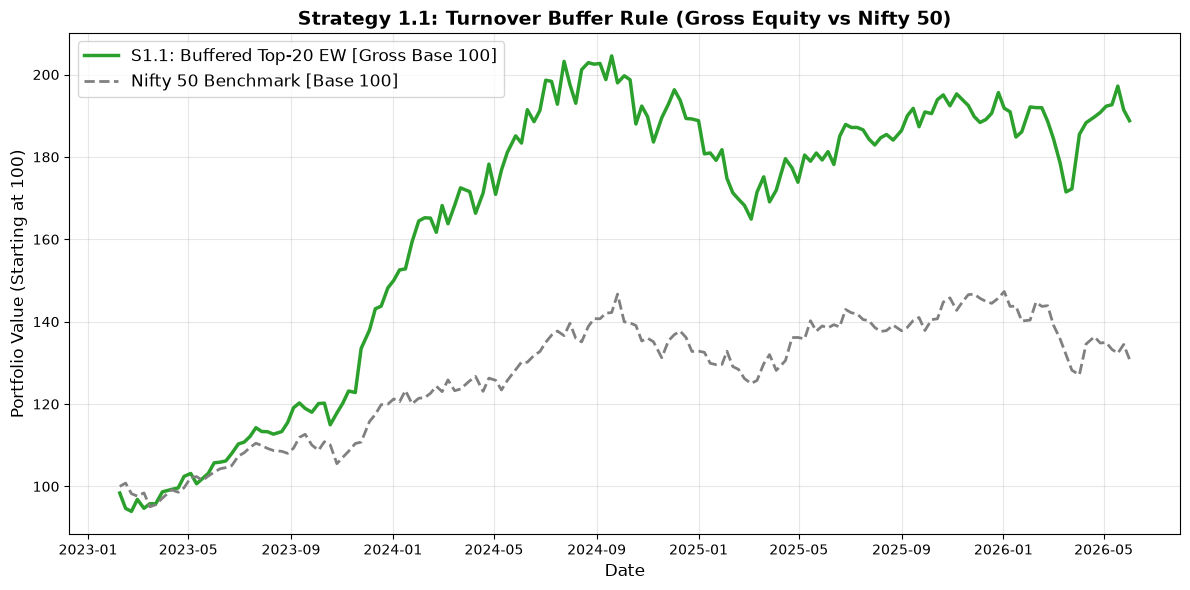

In [659]:
plt.figure(figsize=(12, 6))
plt.plot(s11_port_df.index, s11_equity_100, color='#2ca02c', linewidth=2.5, label='S1.1: Buffered Top-20 EW [Gross Base 100]')

if not nifty_slice.empty:
    nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100
    plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')

plt.title('Strategy 1.1: Turnover Buffer Rule (Gross Equity vs Nifty 50)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 3) Nifty 200 EMA Filter

As we can see that our model s1 is performing very good while market is going up but when market goes down it fails
then why dont we trade only when market is in up trend
for thich i will use EMA
so when nifty is above 200 EMA menas we will have 100% exposure nad then when nifty below 200 EMA we will only use 30% of capital 



In [676]:
def print_institutional_tearsheet(df, strategy_name="Strategy", return_col='Gross_Return', holding_period=5):
    returns = df[return_col].dropna()
    if len(returns) == 0:
        print(f"No returns data found for {strategy_name}.")
        return
        
    equity_curve = (1 + returns).cumprod()
    periods_per_year = 252 / holding_period
    years = len(returns) / periods_per_year
    
    cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1 if years > 0 else 0
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)
    
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
    sortino = cagr / downside_vol if downside_vol != 0 else 0
    
    rolling_max = equity_curve.cummax()
    drawdowns = (equity_curve / rolling_max) - 1
    max_dd = drawdowns.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    dd_groups = (drawdowns == 0).cumsum()
    dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
    max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0
    
    hit_rate = (returns > 0).mean()
    ret_skew = skew(returns)
    ret_kurt = kurtosis(returns)
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    metrics = {
        "CAGR": f"{cagr:.2%}",
        "Annualized Volatility": f"{ann_vol:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Max Drawdown": f"{max_dd:.2%}",
        "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
        "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
        "Return Skewness": f"{ret_skew:.2f}",
        "Return Kurtosis": f"{ret_kurt:.2f}",
        "Weekly VaR (95%)": f"{var_95:.2%}",
        "Weekly CVaR (95%)": f"{cvar_95:.2%}"
    }
    print(pd.DataFrame.from_dict(metrics, orient='index', columns=[strategy_name]).to_string())

In [677]:
# calculating EMA 200

In [678]:
nifty_regime['EMA_200'] = nifty_regime['Nifty'].ewm(span=200, adjust=False).mean()

nifty_regime['Prev_Nifty'] = nifty_regime['Nifty'].shift(1)
nifty_regime['Prev_EMA_200'] = nifty_regime['EMA_200'].shift(1)

nifty_regime['Exposure'] = np.where(nifty_regime['Prev_Nifty'] > nifty_regime['Prev_EMA_200'], 1.0, 0.3)

exposure_map = dict(zip(pd.to_datetime(nifty_regime['Date']), nifty_regime['Exposure']))

In [679]:
K_TARGET = 20
HOLDING_PERIOD = 5

s1_ema_df = df_nn_oos.copy()
s1_ema_df['Date'] = pd.to_datetime(s1_ema_df['Date'])
if 'Fwd_Ret_5D' not in s1_ema_df.columns:
    master_panel['Date'] = pd.to_datetime(master_panel['Date'])
    s1_ema_df = pd.merge(s1_ema_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s1_ema_df['Date'].unique())
rebalance_dates = unique_dates[::HOLDING_PERIOD]

portfolio_returns = []

In [680]:
for date in rebalance_dates:
    day_data = s1_ema_df[s1_ema_df['Date'] == date].dropna(subset=['Pred_Score', 'Fwd_Ret_5D'])
    if day_data.empty:
        continue
    current_exposure = exposure_map.get(date, 1.0)
    
    day_data = day_data.sort_values(by='Pred_Score', ascending=False)
    top_basket = day_data.head(K_TARGET).copy()
    
    if not top_basket.empty:
        basket_return = top_basket['Fwd_Ret_5D'].mean()

        gross_ret = basket_return * current_exposure
    else:
        gross_ret = 0.0
        current_exposure = 0.0
        
    portfolio_returns.append({
        'Date': date,
        'Gross_Return': gross_ret,
        'Exposure': current_exposure
    })
s1_ema_port = pd.DataFrame(portfolio_returns).set_index('Date')
s1_ema_port.index = pd.to_datetime(s1_ema_port.index)
s1_ema_port['Equity_Curve'] = (1 + s1_ema_port['Gross_Return']).cumprod()

print_institutional_tearsheet(s1_ema_port, strategy_name=" (200-EMA Filter)", return_col='Gross_Return', holding_period=HOLDING_PERIOD)

                             (200-EMA Filter)
CAGR                                   20.76%
Annualized Volatility                  14.71%
Sharpe Ratio                             1.36
Sortino Ratio                            2.36
Calmar Ratio                             1.42
Max Drawdown                          -14.57%
Max Drawdown Duration        420 Trading Days
Hit Rate (Positive Periods)            57.93%
Return Skewness                          0.32
Return Kurtosis                          1.80
Weekly VaR (95%)                       -3.09%
Weekly CVaR (95%)                      -3.91%


In [681]:
# Equity Curve

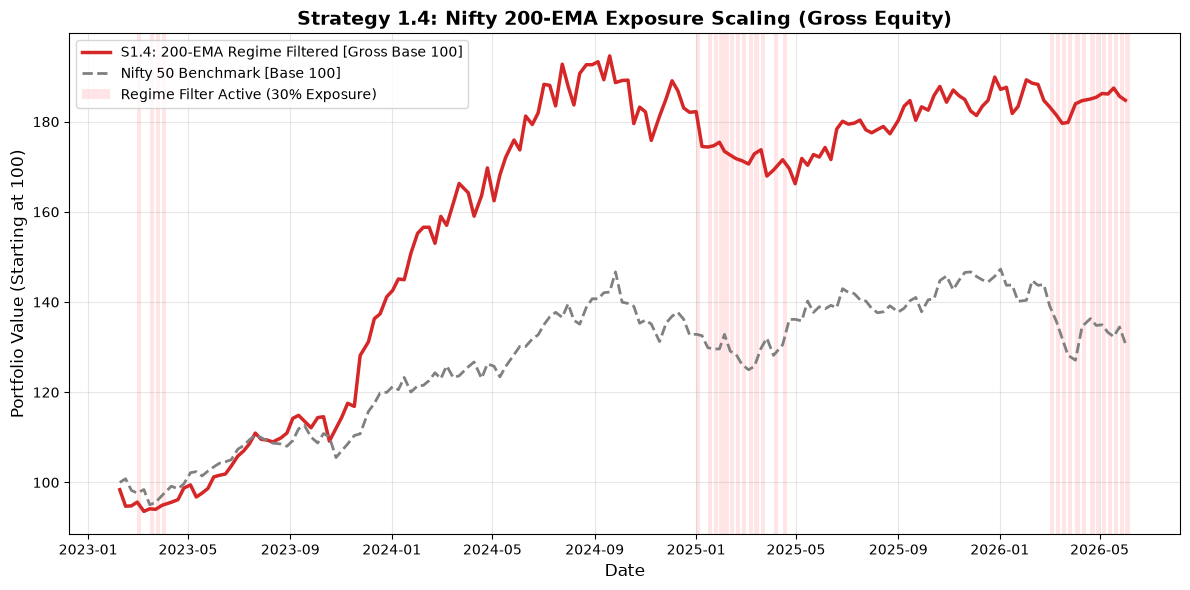

In [684]:
equity_100 = s1_ema_port['Equity_Curve'] * 100

nifty_slice = master_panel[master_panel['Date'].isin(s1_ema_port.index)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()

plt.figure(figsize=(12, 6))
plt.plot(s1_ema_port.index, equity_100, color='#d62728', linewidth=2.5, label='S1.4: 200-EMA Regime Filtered [Gross Base 100]')

if not nifty_slice.empty:
    nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100
    plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')

low_exposure_dates = s1_ema_port[s1_ema_port['Exposure'] == 0.3].index
for d in low_exposure_dates:
    plt.axvspan(d, d + pd.Timedelta(days=HOLDING_PERIOD), color='red', alpha=0.1, lw=0)

plt.title('Strategy 1.4: Nifty 200-EMA Exposure Scaling (Gross Equity)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
from matplotlib.patches import Patch
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(Patch(facecolor='red', alpha=0.1))
labels.append('Regime Filter Active (30% Exposure)')
plt.legend(handles=handles, labels=labels, fontsize=10)
plt.tight_layout()
plt.show()

## 3) MACD Strategy for Execution

### Strategy S1 ( Long on top 20 )

Long with 100 % exposure when MACD centraline is above 0. 

Long with only 20% Exposure ( capital ) when MACD centraline is below 0.


In [697]:
def print_institutional_tearsheet(df, strategy_name="Strategy", return_col='Gross_Return', holding_period=5):
    returns = df[return_col].dropna()
    if len(returns) == 0:
        print(f"No returns data found for {strategy_name}.")
        return
        
    equity_curve = (1 + returns).cumprod()
    periods_per_year = 252 / holding_period
    years = len(returns) / periods_per_year
    
    cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1 if years > 0 else 0
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)
    
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
    sortino = cagr / downside_vol if downside_vol != 0 else 0
    
    rolling_max = equity_curve.cummax()
    drawdowns = (equity_curve / rolling_max) - 1
    max_dd = drawdowns.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    dd_groups = (drawdowns == 0).cumsum()
    dd_duration_periods = drawdowns[drawdowns < 0].groupby(dd_groups).count()
    max_dd_duration_days = (dd_duration_periods.max() * holding_period) if not dd_duration_periods.empty else 0
    
    hit_rate = (returns > 0).mean()
    ret_skew = skew(returns)
    ret_kurt = kurtosis(returns)
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    metrics = {
        "CAGR": f"{cagr:.2%}",
        "Annualized Volatility": f"{ann_vol:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Max Drawdown": f"{max_dd:.2%}",
        "Max Drawdown Duration": f"{max_dd_duration_days} Trading Days",
        "Hit Rate (Positive Periods)": f"{hit_rate:.2%}",
        "Return Skewness": f"{ret_skew:.2f}",
        "Return Kurtosis": f"{ret_kurt:.2f}",
        "Weekly VaR (95%)": f"{var_95:.2%}",
        "Weekly CVaR (95%)": f"{cvar_95:.2%}"
    }
    print(pd.DataFrame.from_dict(metrics, orient='index', columns=[strategy_name]).to_string())

In [699]:
# Nifty MACD calculation ( shifted by 1 to prevent Lookahead Bias)

In [700]:
nifty_regime = master_panel[['Date', 'Nifty']].drop_duplicates().sort_values('Date').reset_index(drop=True)

nifty_regime['EMA_12'] = nifty_regime['Nifty'].ewm(span=12, adjust=False).mean()
nifty_regime['EMA_26'] = nifty_regime['Nifty'].ewm(span=26, adjust=False).mean()
nifty_regime['MACD_Line'] = nifty_regime['EMA_12'] - nifty_regime['EMA_26']

nifty_regime['Prev_MACD'] = nifty_regime['MACD_Line'].shift(1)

nifty_regime['Exposure'] = np.where(nifty_regime['Prev_MACD'] > 0, 1.0, 0.2)

exposure_map = dict(zip(pd.to_datetime(nifty_regime['Date']), nifty_regime['Exposure']))

In [701]:
K_TARGET = 20
HOLDING_PERIOD = 5

s1_macd_df = df_nn_oos.copy()
s1_macd_df['Date'] = pd.to_datetime(s1_macd_df['Date'])
if 'Fwd_Ret_5D' not in s1_macd_df.columns:
    master_panel['Date'] = pd.to_datetime(master_panel['Date'])
    s1_macd_df = pd.merge(s1_macd_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s1_macd_df['Date'].unique())
rebalance_dates = unique_dates[::HOLDING_PERIOD]

portfolio_returns = []

for date in rebalance_dates:
    day_data = s1_macd_df[s1_macd_df['Date'] == date].dropna(subset=['Pred_Score', 'Fwd_Ret_5D'])
    if day_data.empty:
        continue
        
    current_exposure = exposure_map.get(date, 1.0)
    
    day_data = day_data.sort_values(by='Pred_Score', ascending=False)
    top_basket = day_data.head(K_TARGET).copy()
    
    if not top_basket.empty:
        basket_return = top_basket['Fwd_Ret_5D'].mean()
        
        gross_ret = basket_return * current_exposure
    else:
        gross_ret = 0.0
        current_exposure = 0.0
        
    portfolio_returns.append({
        'Date': date,
        'Gross_Return': gross_ret,
        'Exposure': current_exposure
    })


In [707]:
s1_macd_port = pd.DataFrame(portfolio_returns).set_index('Date')
s1_macd_port.index = pd.to_datetime(s1_macd_port.index)
s1_macd_port['Equity_Curve'] = (1 + s1_macd_port['Gross_Return']).cumprod()

print_institutional_tearsheet(s1_macd_port, strategy_name="Strategy 1.5 (MACD Filter > 0)", return_col='Gross_Return', holding_period=HOLDING_PERIOD)

                            Strategy 1.5 (MACD Filter > 0)
CAGR                                                20.75%
Annualized Volatility                               12.91%
Sharpe Ratio                                          1.53
Sortino Ratio                                         2.78
Calmar Ratio                                          2.06
Max Drawdown                                       -10.09%
Max Drawdown Duration                     310 Trading Days
Hit Rate (Positive Periods)                         57.93%
Return Skewness                                       0.86
Return Kurtosis                                       3.75
Weekly VaR (95%)                                    -2.35%
Weekly CVaR (95%)                                   -3.18%


In [708]:
# Equity Curve vs Nifty 50

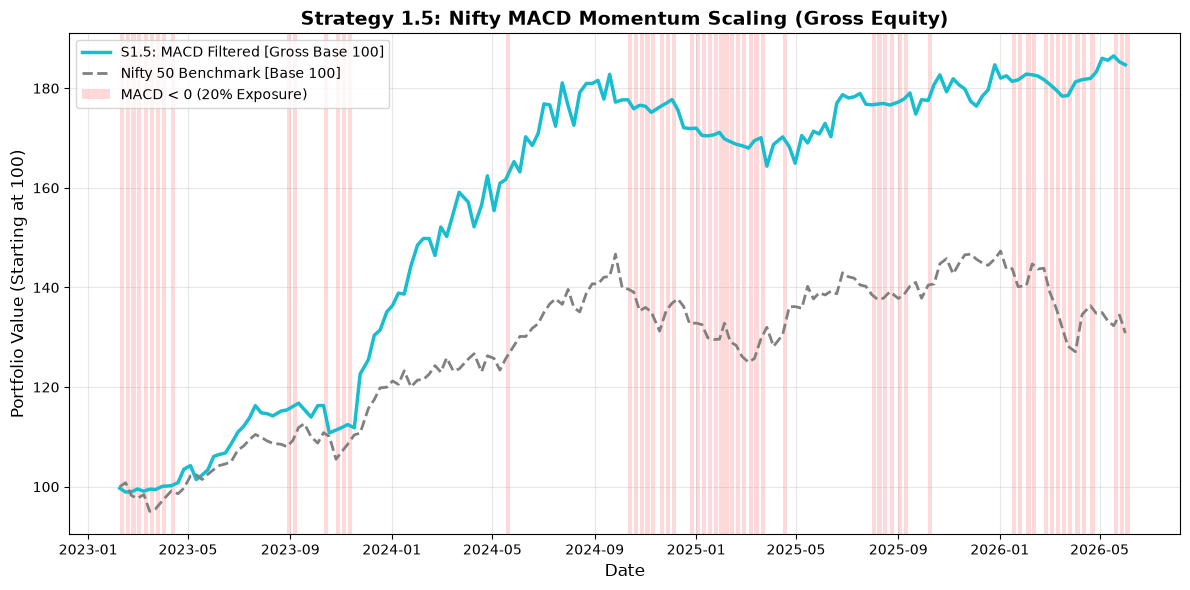

In [709]:
equity_100 = s1_macd_port['Equity_Curve'] * 100

nifty_slice = master_panel[master_panel['Date'].isin(s1_macd_port.index)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()

plt.figure(figsize=(12, 6))
plt.plot(s1_macd_port.index, equity_100, color='#17becf', linewidth=2.5, label='S1.5: MACD Filtered [Gross Base 100]')

if not nifty_slice.empty:
    nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100
    plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark [Base 100]')

low_exposure_dates = s1_macd_port[s1_macd_port['Exposure'] == 0.2].index
for d in low_exposure_dates:
    plt.axvspan(d, d + pd.Timedelta(days=HOLDING_PERIOD), color='red', alpha=0.15, lw=0)

plt.title('Strategy 1.5: Nifty MACD Momentum Scaling (Gross Equity)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)

from matplotlib.patches import Patch
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(Patch(facecolor='red', alpha=0.15))
labels.append('MACD < 0 (20% Exposure)')
plt.legend(handles=handles, labels=labels, fontsize=10)
plt.tight_layout()
plt.show()

Selecting this as our Main strategy as it have the best sharpe ration and lower max drawdown without cutting much on the CAGR

### EXECUTION COST COST ADJUSTED Report


EXECUTION timing = T+1 open 

we observe the nifty MACD and Neural Network scores at the end of the day after market closes ( day 0 )

We will execute the order necxt morning ( T + 1) within firsrt 15 minutes

TRANSACTION COST CALCULATION ( assumptions / average cost )

Brokerage - 3 bps 
STT - 10 bps 
Exchange/GST - 2 bps 
slippage - 5 bps 

Total Average baseline Cost of execution = 20 bps or 0.20 % 

In [712]:
nifty_regime = master_panel[['Date', 'Nifty']].drop_duplicates().sort_values('Date').reset_index(drop=True)
nifty_regime['EMA_12'] = nifty_regime['Nifty'].ewm(span=12, adjust=False).mean()
nifty_regime['EMA_26'] = nifty_regime['Nifty'].ewm(span=26, adjust=False).mean()
nifty_regime['MACD_Line'] = nifty_regime['EMA_12'] - nifty_regime['EMA_26']
nifty_regime['Prev_MACD'] = nifty_regime['MACD_Line'].shift(1)
nifty_regime['Exposure'] = np.where(nifty_regime['Prev_MACD'] > 0, 1.0, 0.2)
exposure_map = dict(zip(pd.to_datetime(nifty_regime['Date']), nifty_regime['Exposure']))

K_TARGET = 20
HOLDING_PERIOD = 5
s1_macd_df = df_nn_oos.copy()
s1_macd_df['Date'] = pd.to_datetime(s1_macd_df['Date'])
if 'Fwd_Ret_5D' not in s1_macd_df.columns:
    master_panel['Date'] = pd.to_datetime(master_panel['Date'])
    s1_macd_df = pd.merge(s1_macd_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s1_macd_df['Date'].unique())
rebalance_dates = unique_dates[::HOLDING_PERIOD]

portfolio_records = []
prev_weights = {}

for date in rebalance_dates:
    day_data = s1_macd_df[s1_macd_df['Date'] == date].dropna(subset=['Pred_Score', 'Fwd_Ret_5D'])
    if day_data.empty:
        continue
        
    current_exposure = exposure_map.get(date, 1.0)
    day_data = day_data.sort_values(by='Pred_Score', ascending=False)
    top_basket = day_data.head(K_TARGET)['Ticker'].tolist()
    
    current_weights = {}
    gross_ret = 0.0
    
    if len(top_basket) > 0:
        weight_per_stock = (1.0 / len(top_basket)) * current_exposure
        for ticker in top_basket:
            current_weights[ticker] = weight_per_stock
            
        port_data = day_data[day_data['Ticker'].isin(top_basket)]
        gross_ret = port_data['Fwd_Ret_5D'].mean() * current_exposure
        
    current_weights['CASH'] = 1.0 - current_exposure
    
    if not prev_weights:
        turnover = current_exposure 
    else:
        all_assets = set(list(current_weights.keys()) + list(prev_weights.keys()))
        weight_diff = sum([abs(current_weights.get(a, 0.0) - prev_weights.get(a, 0.0)) for a in all_assets])
        turnover = weight_diff / 2.0
        
    portfolio_records.append({
        'Date': date,
        'Gross_Return': gross_ret,
        'Turnover': turnover
    })
    
    prev_weights = current_weights.copy()

s15_master_df = pd.DataFrame(portfolio_records).set_index('Date')
s15_master_df.index = pd.to_datetime(s15_master_df.index)


In [711]:
# Cost Sensitivity Pipeline

In [713]:
def apply_transaction_costs(df, one_way_cost_bps, holding_period=5):
    cost_decimal = one_way_cost_bps / 10000.0 
    net_returns = df['Gross_Return'] - (df['Turnover'] * cost_decimal)
    equity_curve = (1 + net_returns).cumprod()
    
    returns = net_returns.dropna()
    periods_per_year = 252 / holding_period
    years = len(returns) / periods_per_year
    
    cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1 if years > 0 else 0
    sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)
    
    rolling_max = equity_curve.cummax()
    max_dd = ((equity_curve / rolling_max) - 1).min()
    
    return net_returns, equity_curve, cagr, sharpe, max_dd


In [714]:
cost_tiers_bps = [0, 10, 20, 30]
sensitivity_results = []
net_curves = {}

for cost_bps in cost_tiers_bps:
    net_rets, eq_curve, cagr, sharpe, max_dd = apply_transaction_costs(s15_master_df, cost_bps, HOLDING_PERIOD)
    net_curves[cost_bps] = eq_curve
    
    sensitivity_results.append({
        'One-Way Cost (bps)': f"{cost_bps} bps",
        'Net CAGR': f"{cagr:.2%}",
        'Net Sharpe Ratio': round(sharpe, 2),
        'Net Max Drawdown': f"{max_dd:.2%}"
    })

sensitivity_df = pd.DataFrame(sensitivity_results).set_index('One-Way Cost (bps)')
print(sensitivity_df.to_string())
print(f"Average Period Turnover: {s15_master_df['Turnover'].mean():.2%}")


                   Net CAGR  Net Sharpe Ratio Net Max Drawdown
One-Way Cost (bps)                                            
0 bps                20.75%              1.53          -10.09%
10 bps               18.42%              1.37          -10.65%
20 bps               16.13%              1.22          -11.30%
30 bps               13.89%              1.07          -12.15%
Average Period Turnover: 38.79%


In [715]:
# Comparision Chart 

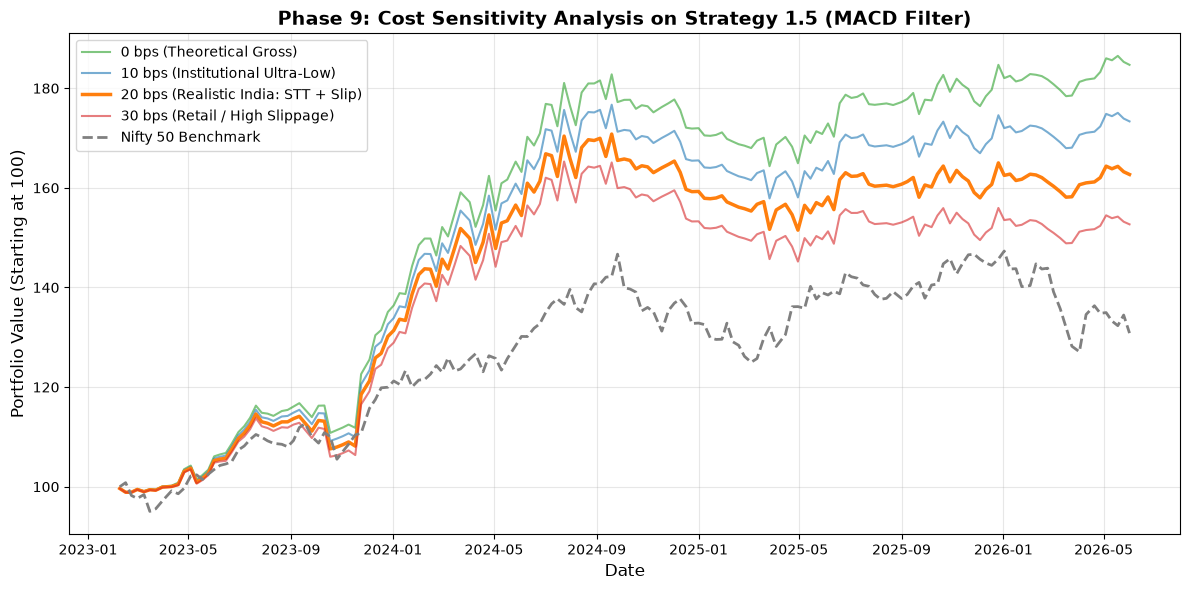

In [716]:
plt.figure(figsize=(12, 6))

colors = {0: '#2ca02c', 10: '#1f77b4', 20: '#ff7f0e', 30: '#d62728'}
labels = {
    0: '0 bps (Theoretical Gross)',
    10: '10 bps (Institutional Ultra-Low)',
    20: '20 bps (Realistic India: STT + Slip)',
    30: '30 bps (Retail / High Slippage)'
}

for cost_bps in cost_tiers_bps:
    curve = net_curves[cost_bps] * 100
    plt.plot(curve.index, curve, color=colors[cost_bps], linewidth=2.5 if cost_bps == 20 else 1.5, 
             alpha=1.0 if cost_bps == 20 else 0.6, label=labels[cost_bps])

nifty_slice = master_panel[master_panel['Date'].isin(s15_master_df.index)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
if not nifty_slice.empty:
    nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100
    plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark')

plt.title('Phase 9: Cost Sensitivity Analysis on Strategy 1.5 (MACD Filter)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

## Cost Optimization 

If we take 20 bps average then this strategy and model is barely outperforming the NIFTY 50. 

I need to reduce the cost or optimize the cost 


### Cost optimization can be done in 2 way  

1) Reduce the Turnover rate - re inject the 15/30 buffer rule from the earlier strategy to reduce the turnover
2) Park the Idle cash into LiquidBees or other Instrument where we can expect 5-6% risk free return. when our model is only using 20 capital in the market then sitting idle with cash is not a good idea

In [719]:
K_TARGET = 20
RANK_BUY_NEW = 15
RANK_SELL_OLD = 30
HOLDING_PERIOD = 5
ANNUAL_CASH_YIELD = 0.06  # 6 percent from fixed asset
PERIOD_CASH_YIELD = (1 + ANNUAL_CASH_YIELD) ** (HOLDING_PERIOD / 252) - 1

nifty_regime = master_panel[['Date', 'Nifty']].drop_duplicates().sort_values('Date').reset_index(drop=True)
nifty_regime['EMA_12'] = nifty_regime['Nifty'].ewm(span=12, adjust=False).mean()
nifty_regime['EMA_26'] = nifty_regime['Nifty'].ewm(span=26, adjust=False).mean()
nifty_regime['MACD_Line'] = nifty_regime['EMA_12'] - nifty_regime['EMA_26']
nifty_regime['Prev_MACD'] = nifty_regime['MACD_Line'].shift(1)
nifty_regime['Exposure'] = np.where(nifty_regime['Prev_MACD'] > 0, 1.0, 0.2)
exposure_map = dict(zip(pd.to_datetime(nifty_regime['Date']), nifty_regime['Exposure']))

s15_df = df_nn_oos.copy()
s15_df['Date'] = pd.to_datetime(s15_df['Date'])
if 'Fwd_Ret_5D' not in s15_df.columns:
    master_panel['Date'] = pd.to_datetime(master_panel['Date'])
    s15_df = pd.merge(s15_df, master_panel[['Date', 'Ticker', 'Fwd_Ret_5D']], on=['Date', 'Ticker'], how='left')

unique_dates = sorted(s15_df['Date'].unique())
rebalance_dates = unique_dates[::HOLDING_PERIOD]

portfolio_records = []
current_holdings = []
prev_weights = {}

In [720]:
for date in rebalance_dates:
    day_data = s15_df[s15_df['Date'] == date].dropna(subset=['Pred_Score', 'Fwd_Ret_5D'])
    if day_data.empty:
        continue
        
    current_exposure = exposure_map.get(date, 1.0)
    day_data['Daily_Rank'] = day_data['Pred_Score'].rank(ascending=False, method='first')
    
    # The 15/30 Buffer Rule
    new_holdings = []
    
    if current_holdings:
        held_data = day_data[day_data['Ticker'].isin(current_holdings)]
        keepers = held_data[held_data['Daily_Rank'] <= RANK_SELL_OLD]['Ticker'].tolist()
        new_holdings.extend(keepers)
        
    space_left = K_TARGET - len(new_holdings)
    if space_left > 0:
        candidates = day_data[(~day_data['Ticker'].isin(new_holdings)) & (day_data['Daily_Rank'] <= RANK_BUY_NEW)].sort_values('Daily_Rank')
        new_holdings.extend(candidates.head(space_left)['Ticker'].tolist())
        
    space_left = K_TARGET - len(new_holdings)
    if space_left > 0:
        fillers = day_data[~day_data['Ticker'].isin(new_holdings)].sort_values('Daily_Rank').head(space_left)['Ticker'].tolist()
        new_holdings.extend(fillers)
    
    # Weight Assignment & Returns
    current_weights = {}
    gross_ret = 0.0
    
    if len(new_holdings) > 0:
        weight_per_stock = (1.0 / len(new_holdings)) * current_exposure
        for ticker in new_holdings:
            current_weights[ticker] = weight_per_stock
            
        port_data = day_data[day_data['Ticker'].isin(new_holdings)]
        equity_return = port_data['Fwd_Ret_5D'].mean() * current_exposure
    else:
        equity_return = 0.0
        
    # Add Cash Yield 
    cash_weight = 1.0 - current_exposure
    current_weights['CASH'] = cash_weight
    cash_return = cash_weight * PERIOD_CASH_YIELD
    
    gross_ret = equity_return + cash_return
    
    # 2C. Strict Turnover
    if not prev_weights:
        turnover = current_exposure 
    else:
        all_assets = set(list(current_weights.keys()) + list(prev_weights.keys()))
        weight_diff = sum([abs(current_weights.get(a, 0.0) - prev_weights.get(a, 0.0)) for a in all_assets])
        # We don't pay 20 bps STT on liquidating cash, so we exclude the cash weight difference from the penalty
        equity_weight_diff = sum([abs(current_weights.get(a, 0.0) - prev_weights.get(a, 0.0)) for a in all_assets if a != 'CASH'])
        turnover = equity_weight_diff / 2.0
        
    portfolio_records.append({
        'Date': date,
        'Gross_Return': gross_ret,
        'Turnover': turnover
    })
    
    current_holdings = new_holdings.copy()
    prev_weights = current_weights.copy()

s15_master_df = pd.DataFrame(portfolio_records).set_index('Date')
s15_master_df.index = pd.to_datetime(s15_master_df.index)

In [721]:
# cost sensitivity calculation

In [722]:
def apply_transaction_costs(df, one_way_cost_bps, holding_period=5):
    cost_decimal = one_way_cost_bps / 10000.0 
    net_returns = df['Gross_Return'] - (df['Turnover'] * cost_decimal)
    equity_curve = (1 + net_returns).cumprod()
    
    returns = net_returns.dropna()
    periods_per_year = 252 / holding_period
    years = len(returns) / periods_per_year
    
    cagr = (equity_curve.iloc[-1] ** (1 / years)) - 1 if years > 0 else 0
    sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)
    
    rolling_max = equity_curve.cummax()
    max_dd = ((equity_curve / rolling_max) - 1).min()
    
    return net_returns, equity_curve, cagr, sharpe, max_dd


In [723]:
cost_tiers_bps = [0, 10, 20, 30]
sensitivity_results = []
net_curves = {}

for cost_bps in cost_tiers_bps:
    net_rets, eq_curve, cagr, sharpe, max_dd = apply_transaction_costs(s15_master_df, cost_bps, HOLDING_PERIOD)
    net_curves[cost_bps] = eq_curve
    
    sensitivity_results.append({
        'One-Way Cost (bps)': f"{cost_bps} bps",
        'Net CAGR': f"{cagr:.2%}",
        'Net Sharpe Ratio': round(sharpe, 2),
        'Net Max Drawdown': f"{max_dd:.2%}"
    })

sensitivity_df = pd.DataFrame(sensitivity_results).set_index('One-Way Cost (bps)')
print(sensitivity_df.to_string())
print(f"Average Period Turnover (Equity Only): {s15_master_df['Turnover'].mean():.2%}")


                   Net CAGR  Net Sharpe Ratio Net Max Drawdown
One-Way Cost (bps)                                            
0 bps                21.19%              1.55           -9.50%
10 bps               19.73%              1.46           -9.95%
20 bps               18.29%              1.36          -10.40%
30 bps               16.86%              1.27          -10.93%
Average Period Turnover (Equity Only): 24.12%


In [725]:
# Equity curve vs Nifty for the final strategy with cost adjusted

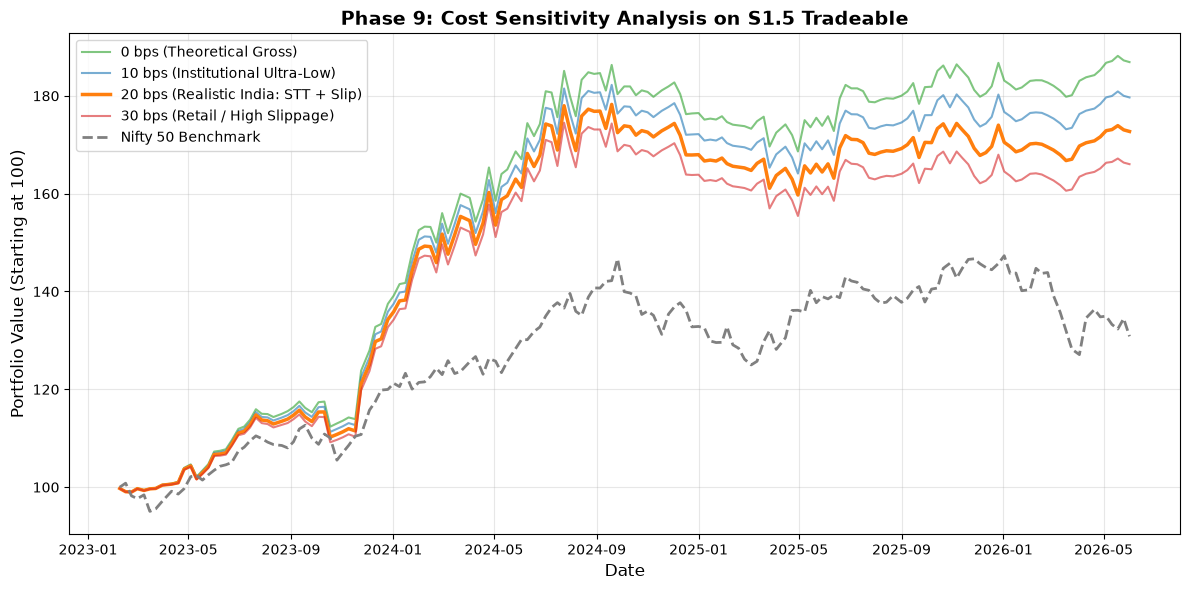

In [726]:
plt.figure(figsize=(12, 6))

colors = {0: '#2ca02c', 10: '#1f77b4', 20: '#ff7f0e', 30: '#d62728'}
labels = {
    0: '0 bps (Theoretical Gross)',
    10: '10 bps (Institutional Ultra-Low)',
    20: '20 bps (Realistic India: STT + Slip)',
    30: '30 bps (Retail / High Slippage)'
}

for cost_bps in cost_tiers_bps:
    curve = net_curves[cost_bps] * 100
    plt.plot(curve.index, curve, color=colors[cost_bps], linewidth=2.5 if cost_bps == 20 else 1.5, 
             alpha=1.0 if cost_bps == 20 else 0.6, label=labels[cost_bps])

nifty_slice = master_panel[master_panel['Date'].isin(s15_master_df.index)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()
if not nifty_slice.empty:
    nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100
    plt.plot(nifty_base_100.index, nifty_base_100, color='gray', linestyle='--', linewidth=2, label='Nifty 50 Benchmark')

plt.title('Phase 9: Cost Sensitivity Analysis on S1.5 Tradeable', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

## FINAL STRATEGY ( Assuming Cost = 20 Bps )

1. Rebalance frequency - 5 days
2. Portfolio size - Top 20 stock ( all equal weighted )
3. 15/30 Turnover buffer 
4. MACD ( macd>0 = 100% exposure),(macd<0 = 20 % exposure_map)
5. Ilde capital = 6% annualised return

In [732]:
cost_bps_champion = 20
cost_decimal = cost_bps_champion / 10000.0 

champion_df = s15_master_df.copy()
champion_df['Net_Return'] = champion_df['Gross_Return'] - (champion_df['Turnover'] * cost_decimal)
champion_df['Equity_Curve'] = (1 + champion_df['Net_Return']).cumprod()

returns = champion_df['Net_Return'].dropna()
gross_returns = champion_df['Gross_Return'].dropna()
periods_per_year = 252 / HOLDING_PERIOD
years = len(returns) / periods_per_year

net_cagr = (champion_df['Equity_Curve'].iloc[-1] ** (1 / years)) - 1 if years > 0 else 0
net_sharpe = (returns.mean() / (returns.std() + 1e-12)) * np.sqrt(periods_per_year)

rolling_max = champion_df['Equity_Curve'].cummax()
net_max_dd = ((champion_df['Equity_Curve'] / rolling_max) - 1).min()
avg_turnover = champion_df['Turnover'].mean()

rolling_6m_returns = returns.rolling(window=int(252/HOLDING_PERIOD/2)).apply(lambda x: (x.mean() / (x.std() + 1e-12)) * np.sqrt(periods_per_year))
worst_6m_sharpe = rolling_6m_returns.min()

gross_sharpe = (gross_returns.mean() / (gross_returns.std() + 1e-12)) * np.sqrt(periods_per_year)
cost_sensitivity_score = (net_sharpe / gross_sharpe) if gross_sharpe != 0 else 0

leaderboard = {
    "Net Sharpe Ratio": f"{net_sharpe:.2f}",
    "Net CAGR": f"{net_cagr:.2%}",
    "Net Max Drawdown": f"{net_max_dd:.2%}",
    "Average Period Turnover": f"{avg_turnover:.2%}",
    "Worst Rolling 6M Sharpe": f"{worst_6m_sharpe:.2f}",
    "Cost Sensitivity Score (Sharpe Retained)": f"{cost_sensitivity_score:.2%}"
}
print(pd.DataFrame.from_dict(leaderboard, orient='index', columns=['Final Strategy']).to_string())

                                         Final Strategy
Net Sharpe Ratio                                   1.36
Net CAGR                                         18.29%
Net Max Drawdown                                -10.40%
Average Period Turnover                          24.12%
Worst Rolling 6M Sharpe                           -1.95
Cost Sensitivity Score (Sharpe Retained)         87.79%


In [733]:
# Equity Curve for Final Strategy

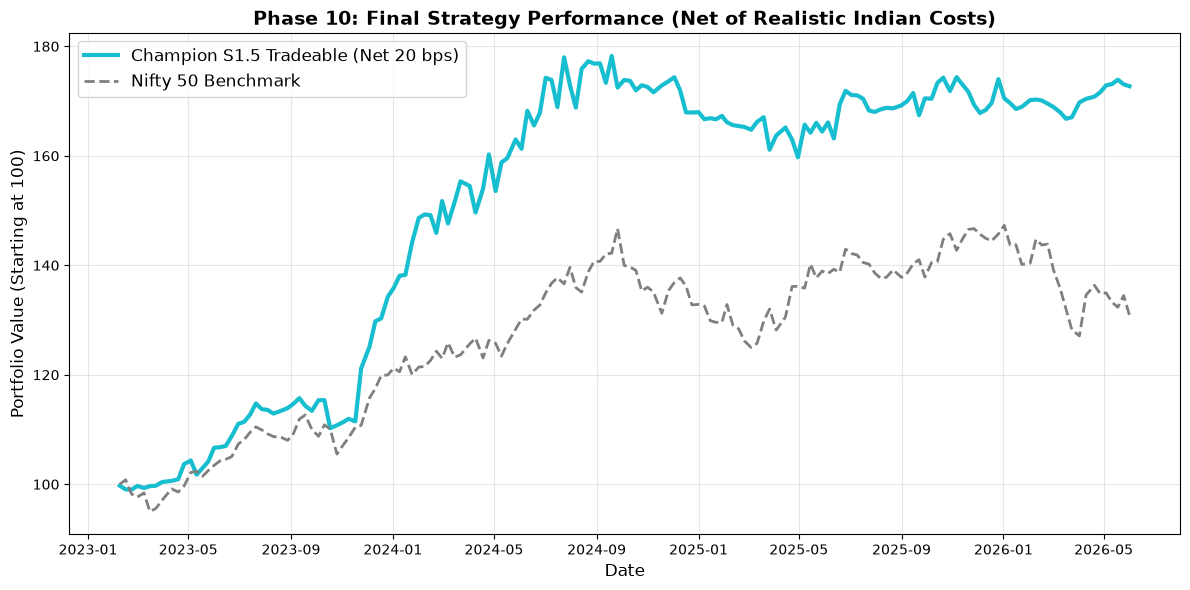

In [734]:
plt.figure(figsize=(12, 6))
equity_100 = champion_df['Equity_Curve'] * 100
plt.plot(champion_df.index, equity_100, color='#17becf', linewidth=3, label='Champion S1.5 Tradeable (Net 20 bps)')

nifty_slice = master_panel[master_panel['Date'].isin(champion_df.index)][['Date', 'Nifty']].drop_duplicates()
nifty_slice['Date'] = pd.to_datetime(nifty_slice['Date'])
nifty_slice = nifty_slice.set_index('Date').sort_index()

if not nifty_slice.empty:
    nifty_base_100 = (nifty_slice['Nifty'] / nifty_slice['Nifty'].iloc[0]) * 100
    plt.plot(nifty_base_100.index, nifty_base_100, color='#7f7f7f', linestyle='--', linewidth=2, label='Nifty 50 Benchmark')

plt.title('Phase 10: Final Strategy Performance (Net of Realistic Indian Costs)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value (Starting at 100)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Save Model & Artifacts for Live Inference
import torch
import pickle
import os

print('Saving artifacts for web pipeline...')
# Save PyTorch weights
torch.save(model.state_dict(), 'quantmlp.pth')

# Save LabelEncoder classes (to map Ticker IDs)
if 'le' in locals():
    with open('ticker_encoder.pkl', 'wb') as f:
        pickle.dump(le.classes_, f)

# Save feature list so predictor knows exact column order
with open('features_list.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Successfully saved quantmlp.pth, ticker_encoder.pkl, and features_list.pkl!')

